# Physics-Informed Recovery for Noisy Hyperspectral Data

This notebook investigates how to preprocess noisy neutron transmission
data so that SAMMY (the R-matrix fitting engine) can fit it correctly.

**Key insight**: SAMMY is the physics engine and must remain the fitting
engine. The question is: what preprocessing recovers enough signal for
SAMMY to converge?

## Progressive Investigation

| Stage | Question | Method |
|-------|----------|--------|
| 1 | Is our noise model valid? | Binning sweep + NNLS gate check |
| 2 | Can SAMMY absorb the noise alone? | Per-pixel SAMMY on noisy data |
| 3 | Does classical denoising help SAMMY? | Median / Savitzky-Golay + SAMMY |
| 4 | Do NMF-based approaches help SAMMY? | Blind NMF / Semi-NMF + SAMMY |

Each stage builds on the previous stage's failure, creating a clear
narrative for why physics-informed preprocessing is necessary.

### Test Data

LANL-ORNL synthetic two-isotope sample (256x256, 500 energy bins, 1-50 eV):
- **ORNL logo** (oak leaf): U-235 at 0.4 g/cm^2
- **LANL logo** (atom/orbital): Pu-241 at 0.2 g/cm^2

In [1]:
import os
# Must set BEFORE any pleiades import (which loads tqdm internally)
os.environ["TQDM_DISABLE"] = "1"

import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import median_filter
from scipy.signal import savgol_filter

from pleiades.imaging import (
    HyperspectralLoader,
    ResultsAggregator,
    AbundanceMapGenerator,
    AbundanceMapVisualizer,
    Imaging2DResults,
    SparsityAssessor,
    DataDegrader,
    SpatialBinner,
    PhysicsRecovery,
    NMFRecovery,
    analyze_imaging,
)
from pleiades.imaging.config import ImagingConfig
from pleiades.imaging.orchestrator import BatchFittingOrchestrator
from pleiades.utils.logger import configure_logger

configure_logger(console_level="WARNING")

# Save all figures here for visual inspection
DEBUG_DIR = Path("../../_debug_images")
DEBUG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    """Save figure to _debug_images/ and display it."""
    fig.savefig(DEBUG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print("Imports OK (tqdm suppressed)")

Imports OK (tqdm suppressed)


In [2]:
# --- Helper functions and representative pixels ---
# These pixels were identified from the clean NNLS ground truth maps:
#   Pure U-235 zone (ORNL oak leaf):     row=155, col=47
#   Pure Pu-241 zone (LANL atom):        row=112, col=174
#   Overlap zone (both logos):           row=136, col=223
REP_PIXELS = {
    "Pure U-235": (155, 47),
    "Pure Pu-241": (112, 174),
    "Overlap": (136, 223),
}

SAMMY_STRIDE = 16  # 16x16 = 256 pixels, ~30s per SAMMY run with 12 workers

import tempfile
import tifffile


def write_temp_tiff(data_cube):
    """Write a (n_energy, H, W) cube to a temp TIFF, return Path."""
    tmp = tempfile.NamedTemporaryFile(suffix=".tif", delete=False)
    tifffile.imwrite(tmp.name, data_cube.astype(np.float32))
    return Path(tmp.name)


def run_sammy_strided(data_cube, stride=SAMMY_STRIDE):
    """Run analyze_imaging with stride on a data cube, return results."""
    tmp_path = write_temp_tiff(data_cube)
    try:
        result = analyze_imaging(
            source=tmp_path,
            imaging_config=config,
            sammy_executable=sammy_executable,
            energy=energy,
            n_workers=N_WORKERS,
            stride=stride,
            timeout_per_job=300.0,
            max_retries=1,
        )
        return result
    finally:
        tmp_path.unlink(missing_ok=True)


def plot_abundance_maps(result, label, stride=SAMMY_STRIDE):
    """Plot U-235 and Pu-241 abundance maps from a strided result."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for i, iso in enumerate(config.isotopes):
        amap = result.abundance_maps[i]
        # Extract the strided sub-grid for display
        sub = amap[::stride, ::stride]
        im = axes[i].imshow(sub, cmap="viridis", origin="upper",
                            interpolation="nearest", vmin=0, vmax=1)
        axes[i].set_title(f"{iso}")
        fig.colorbar(im, ax=axes[i], shrink=0.8)
    fig.suptitle(label, y=1.02)
    fig.tight_layout()
    return fig


def plot_difference_maps(result, gt_result, label, stride=SAMMY_STRIDE):
    """Plot (result - ground_truth) difference maps for each isotope."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for i, iso in enumerate(config.isotopes):
        diff = result.abundance_maps[i] - gt_result.abundance_maps[i]
        sub = diff[::stride, ::stride]
        vmax = max(0.3, np.nanmax(np.abs(sub[np.isfinite(sub)])) if np.any(np.isfinite(sub)) else 0.3)
        im = axes[i].imshow(sub, cmap="RdBu_r", origin="upper",
                            interpolation="nearest", vmin=-vmax, vmax=vmax)
        axes[i].set_title(f"{iso} difference")
        fig.colorbar(im, ax=axes[i], shrink=0.8)
    fig.suptitle(f"{label} (red=overestimate, blue=underestimate)", y=1.02)
    fig.tight_layout()
    return fig


# High-contrast color palette for spectral plots
SPEC_COLORS = {
    "Clean": "black",
    "Noisy": "#d62728",       # red
    "Median": "#2ca02c",      # green
    "Savitzky-Golay": "#1f77b4",  # blue
    "Moving Avg": "#ff7f0e",  # orange
    "NMF Denoised": "#9467bd", # purple
    "Semi-NMF Recon": "#e377c2", # pink
}

def _get_color(label):
    """Get a distinct color for a given label."""
    for key, color in SPEC_COLORS.items():
        if key.lower() in label.lower():
            return color
    # Fallback: cycle through a short list
    fallback = ["#17becf", "#bcbd22", "#8c564b", "#7f7f7f"]
    return fallback[hash(label) % len(fallback)]


def plot_spectra_at_pixels(data_cubes, labels, title_suffix=""):
    """Plot spectra at 3 representative pixels using scatter for noisy data.

    data_cubes: list of (n_energy, H, W) arrays
    labels: list of string labels for each cube

    Top row: transmission spectra (clean=line, others=scatter)
    Bottom row: residual vs clean (scatter)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for col, (pix_label, (pr, pc)) in enumerate(REP_PIXELS.items()):
        ax_top = axes[0, col]
        for idx, (cube, lbl) in enumerate(zip(data_cubes, labels)):
            color = _get_color(lbl)
            y = cube[:, pr, pc]
            if idx == 0:
                # Clean data: solid line
                ax_top.plot(energy, y, lw=1.2, color=color, label=lbl, zorder=10)
            else:
                # Noisy/processed: small scatter points
                ax_top.scatter(energy, y, s=1, alpha=0.5, color=color, label=lbl, zorder=5-idx)
        ax_top.set_title(f"{pix_label} ({pr},{pc})")
        ax_top.set_ylabel("Transmission")
        ax_top.set_ylim(-0.05, 1.15)
        ax_top.legend(fontsize=7, markerscale=5)

        # Bottom: residual vs clean (scatter)
        ax_bot = axes[1, col]
        clean = data_cubes[0][:, pr, pc]
        for idx, (cube, lbl) in enumerate(zip(data_cubes[1:], labels[1:]), 1):
            color = _get_color(lbl)
            residual = cube[:, pr, pc] - clean
            ax_bot.scatter(energy, residual, s=1, alpha=0.5, color=color, label=lbl)
        ax_bot.axhline(0, color="black", lw=0.5, ls="--")
        ax_bot.set_title(f"Residual vs clean")
        ax_bot.set_ylabel("T(method) - T(clean)")
        ax_bot.set_xlabel("Energy (eV)")
        ax_bot.legend(fontsize=7, markerscale=5)

    fig.suptitle(f"Spectral Comparison at Representative Pixels{title_suffix}", y=1.02)
    fig.tight_layout()
    return fig


print(f"Helpers loaded. Representative pixels: {REP_PIXELS}")
print(f"SAMMY stride: {SAMMY_STRIDE} -> {256//SAMMY_STRIDE}x{256//SAMMY_STRIDE} = "
      f"{(256//SAMMY_STRIDE)**2} pixels per run")


Helpers loaded. Representative pixels: {'Pure U-235': (155, 47), 'Pure Pu-241': (112, 174), 'Overlap': (136, 223)}
SAMMY stride: 16 -> 16x16 = 256 pixels per run


In [3]:
# --- Configuration ---
sammy_executable = Path("/Users/8cz/code-int.ornl.gov/sammy/build/bin/sammy")
tiff_path = Path("../../tests/data/pleiades_data/LANL-ORNL_example.tif")
energy = np.linspace(1.0, 50.0, 500)

N_WORKERS = min(12, os.cpu_count() or 4)

config = ImagingConfig(
    isotopes=["U-235", "Pu-241"],
    element="U",
    mass_number=235,
    density_g_cm3=19.1,
    thickness_mm=0.21,
    atomic_mass_amu=235.0439,
    natural_abundances=False,
    custom_abundances=[0.5, 0.5],
    min_energy_eV=1.0,
    max_energy_eV=50.0,
    temperature_K=293.6,
    fit_abundances=True,
)

print(f"SAMMY: {sammy_executable}")
print(f"Workers: {N_WORKERS}")
print(f"Isotopes: {config.isotopes}")

SAMMY: /Users/8cz/code-int.ornl.gov/sammy/build/bin/sammy
Workers: 12
Isotopes: ['U-235', 'Pu-241']


In [4]:
# --- Load clean data (ground truth) ---
loader = HyperspectralLoader(tiff_path, energy=energy)
hyperspectral = loader.load()

hyperspectral.uncertainty = np.maximum(
    hyperspectral.uncertainty,
    0.02 * np.abs(hyperspectral.data) + 1e-4,
).astype(np.float32)

n_energy, height, width = hyperspectral.shape
print(f"Shape: {height}x{width} pixels, {n_energy} energy bins")
print(f"Energy: {energy[0]:.1f} - {energy[-1]:.1f} eV")

# --- Generate SAMMY reference spectra (used throughout) ---
recovery = PhysicsRecovery(imaging_config=config, sammy_executable=sammy_executable)
ref_spectra = recovery.generate_reference_spectra(energy)
print(f"\nReference spectra: {[r.isotope_name for r in ref_spectra]}")
for ref in ref_spectra:
    print(f"  {ref.isotope_name}: T range [{ref.transmission.min():.4f}, {ref.transmission.max():.4f}]")

Shape: 256x256 pixels, 500 energy bins
Energy: 1.0 - 50.0 eV



Reference spectra: ['U-235', 'Pu-241']
  U-235: T range [0.3233, 1.0000]
  Pu-241: T range [0.0603, 1.0000]


Ground truth (NNLS on clean data):
  U-235: mean=0.6037, std=0.2133
  Pu-241: mean=0.3963, std=0.2133


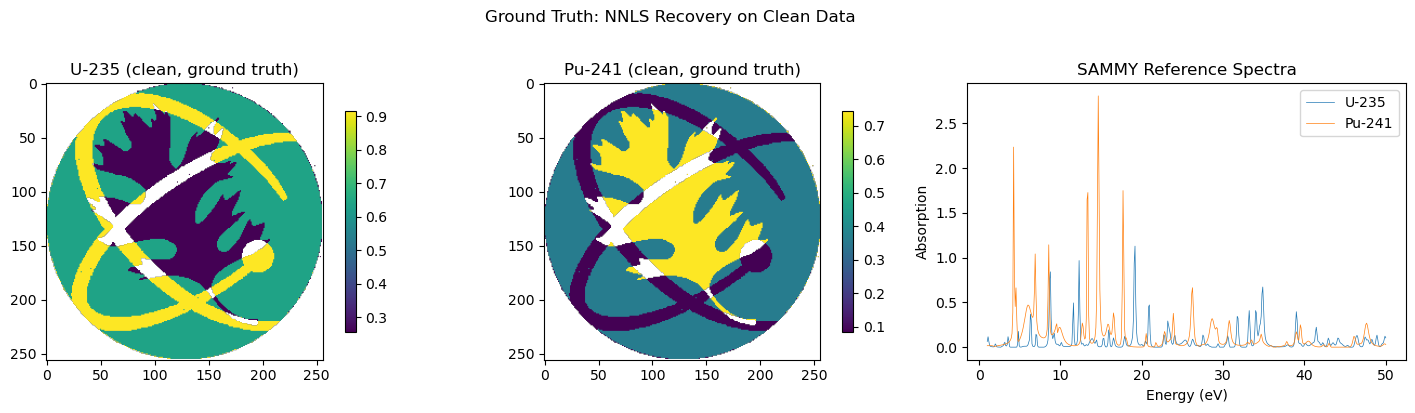

In [5]:
# --- Ground truth: NNLS on clean data ---
results_clean = recovery.recover_image(hyperspectral, reference_spectra=ref_spectra)

print("Ground truth (NNLS on clean data):")
for i, iso in enumerate(results_clean.isotope_names):
    valid = results_clean.abundance_maps[i][results_clean.success_mask]
    print(f"  {iso}: mean={np.nanmean(valid):.4f}, std={np.nanstd(valid):.4f}")

# Visualize ground truth
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, iso in enumerate(results_clean.isotope_names):
    im = axes[i].imshow(results_clean.abundance_maps[i], cmap="viridis", origin="upper")
    axes[i].set_title(f"{iso} (clean, ground truth)")
    fig.colorbar(im, ax=axes[i], shrink=0.8)
axes[2].plot(energy, ref_spectra[0].absorption, label=ref_spectra[0].isotope_name, lw=0.5)
axes[2].plot(energy, ref_spectra[1].absorption, label=ref_spectra[1].isotope_name, lw=0.5)
axes[2].set_xlabel("Energy (eV)")
axes[2].set_ylabel("Absorption")
axes[2].set_title("SAMMY Reference Spectra")
axes[2].legend()
fig.suptitle("Ground Truth: NNLS Recovery on Clean Data", y=1.02)
fig.tight_layout()
save_fig(fig, "00_ground_truth")

---

# Stage 1: Validate the Noise Model

**Question**: Does our Poisson noise model produce realistic degradation, and
can we recover the correct abundances at *some* binning level?

**Method**:
1. Apply Poisson noise at multiple count levels (n_incident = 2, 5, 10, 50, 500)
2. For each noise level, test spatial binning at 1x1, 2x2, 4x4, 8x8, 16x16,
   32x32, and full detector collapse (256x256 = point detector)
3. Run NNLS with SAMMY references at each binning level as a quick check

**Gate**: If the point detector (full collapse to single spectrum) cannot
recover the correct abundances, our noise model is wrong -- stop and fix.

### What is `n_incident`?

`n_incident` controls the **photon count per pixel per energy bin** in our Poisson noise model.
It simulates the statistical nature of neutron detection:

**Physical picture**: A neutron source fires neutrons at a sample. Some are absorbed
(at resonance energies), some pass through. A detector behind the sample counts arrivals.
If the true transmission is T=0.8 and we send `n_incident=100` neutrons at that energy bin,
the detector expects ~80 counts, but the actual number follows a Poisson distribution:
`detected ~ Poisson(n_incident * T)`. The measured transmission is `detected / n_incident`.

**SNR scaling**: Signal-to-noise ratio scales as `sqrt(n_incident)`:

| n_incident | Expected counts (T=0.8) | Noise std | Relative noise | Regime |
|-----------|-------------------------|-----------|----------------|--------|
| 2 | 1.6 | ~1.3 | ~80% | Extreme — barely above shot noise |
| 10 | 8 | ~2.8 | ~35% | Heavy — resonance dips buried |
| 50 | 40 | ~6.3 | ~16% | Moderate — features visible but noisy |
| 500 | 400 | ~20 | ~5% | Mild — clean enough for direct fitting |
| 5000 | 4000 | ~63 | ~1.6% | Clean — typical long-exposure experiment |

**Real-world context**: Long counting times at high-flux sources (SNS, LANSCE) achieve
n_incident in the thousands to millions. But advanced imaging modalities — pulsed sources,
small beam spots, Bragg-edge imaging, fast time-of-flight — can genuinely reach very low
counts per pixel per energy bin. The VENUS beamline at SNS faces exactly this challenge
for spatially-resolved resonance imaging.

Our test at `n_incident=2` is deliberately extreme — each pixel sees only ~2 neutrons per
energy bin. This is the regime where every method we try should struggle, and the question
becomes: *which method degrades most gracefully?*


n_incident Severity                            SNR    Zero%
------------------------------------------------------------


         2 L3: Heavy sparse                   33.0    16.3%


         5 L1: Mild noise                     26.5     1.3%


        10 L0: Clean                          23.8     0.1%


        50 L0: Clean                          18.3     0.0%


       500 L0: Clean                          13.2     0.0%


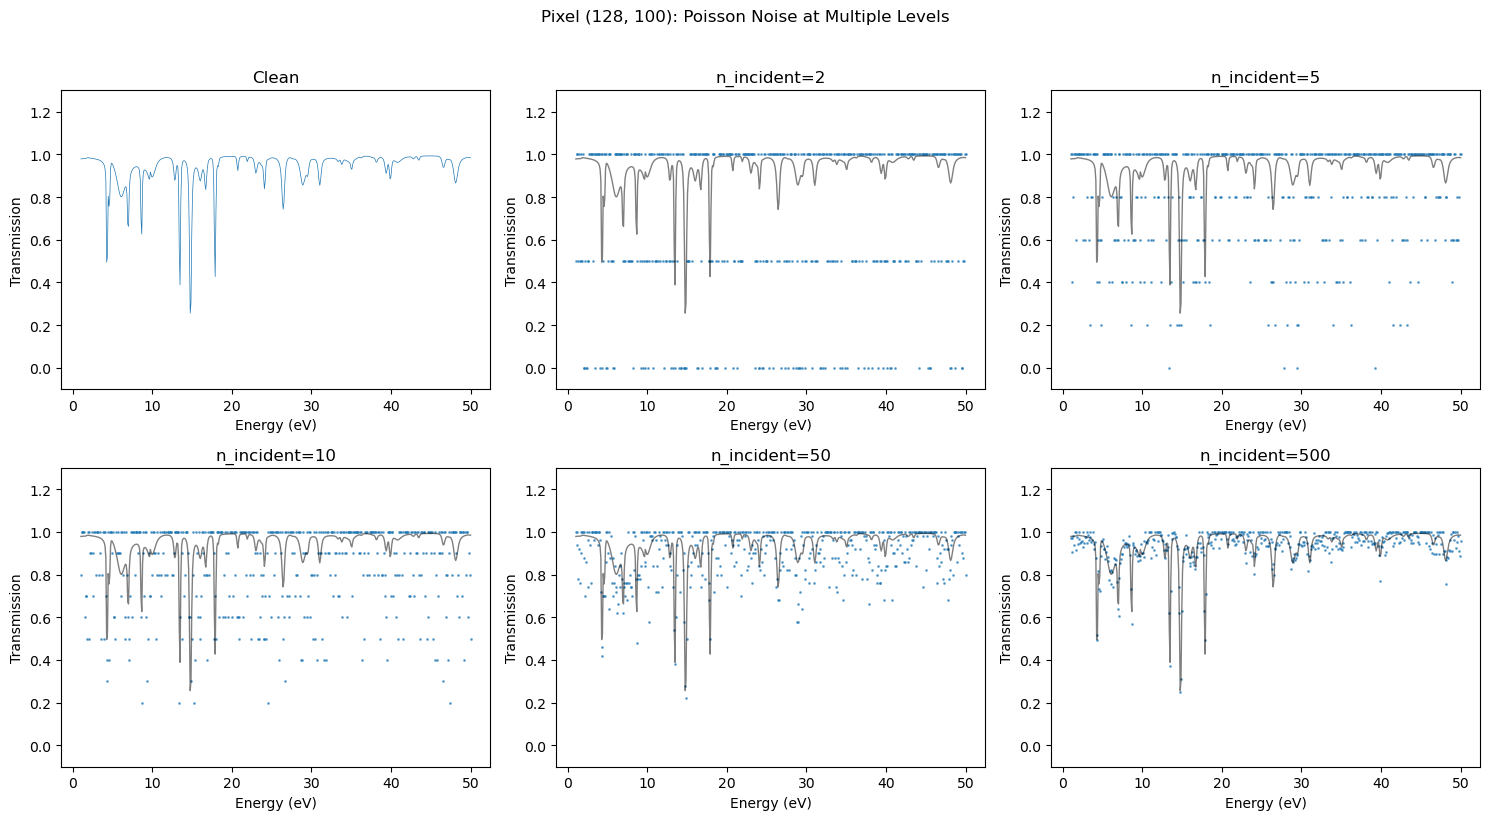

In [6]:
# --- Generate noisy datasets at multiple count levels ---
noise_levels = [2, 5, 10, 50, 500]
noisy_data = {}
assessor = SparsityAssessor()

print(f"{'n_incident':>10} {'Severity':<30} {'SNR':>8} {'Zero%':>8}")
print("-" * 60)

for n_inc in noise_levels:
    degrader = DataDegrader(random_seed=42)
    data_noisy = degrader.add_poisson_noise(hyperspectral.data, n_incident=n_inc)
    noisy_data[n_inc] = data_noisy

    hs_tmp = type(hyperspectral)(
        data=data_noisy, energy=energy, source_file=hyperspectral.source_file,
    )
    m = assessor.assess(hs_tmp)
    print(f"{n_inc:>10} {m.severity_label:<30} {m.snr_estimate:>8.1f} {m.zero_fraction*100:>7.1f}%")

# Visualize a representative pixel across all noise levels
pix_r, pix_c = 128, 100
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

axes[0].plot(energy, hyperspectral.data[:, pix_r, pix_c], lw=0.5)
axes[0].set_title("Clean")
axes[0].set_ylim(-0.1, 1.3)

for idx, n_inc in enumerate(noise_levels):
    ax = axes[idx + 1]
    ax.scatter(energy, noisy_data[n_inc][:, pix_r, pix_c], s=1, alpha=0.6, color='C0')
    ax.plot(energy, hyperspectral.data[:, pix_r, pix_c], lw=1.0, alpha=0.5, color='black')
    ax.set_title(f"n_incident={n_inc}")
    ax.set_ylim(-0.1, 1.3)

for ax in axes:
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Transmission")

fig.suptitle(f"Pixel ({pix_r}, {pix_c}): Poisson Noise at Multiple Levels", y=1.02)
fig.tight_layout()
save_fig(fig, "01_noise_levels")

In [7]:
# --- Binning sweep: for each noise level, test multiple bin sizes ---
# At each (noise_level, bin_size), run NNLS and compute mean absolute error
# against the clean ground truth.

bin_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
# Build reference dictionary for manual NNLS
ref_dict = np.column_stack([r.absorption for r in ref_spectra])  # (n_energy, n_isotopes)

results_sweep = {}  # (n_inc, bin_size) -> {"u235_mae": float, "pu241_mae": float, ...}

for n_inc in noise_levels:
    for bs in bin_sizes:
        if bs > 256:
            continue
        # Create noisy hyperspectral
        hs_noisy = type(hyperspectral)(
            data=noisy_data[n_inc], energy=energy,
            uncertainty=np.maximum(0.02 * np.abs(noisy_data[n_inc]) + 1e-4, 1e-4).astype(np.float32),
            source_file=hyperspectral.source_file,
        )

        # Bin if needed
        if bs > 1:
            binner = SpatialBinner(bin_size=bs)
            hs_binned = binner.bin_hyperspectral(hs_noisy)
        else:
            hs_binned = hs_noisy

        # Run NNLS on binned data
        result = recovery.recover_image(hs_binned, reference_spectra=ref_spectra)

        # Compute error against ground truth (need to bin ground truth too for fair comparison)
        if bs > 1:
            gt_binned = binner.bin_hyperspectral(type(hyperspectral)(
                data=hyperspectral.data, energy=energy, source_file=hyperspectral.source_file,
            ))
            gt_result = recovery.recover_image(gt_binned, reference_spectra=ref_spectra)
        else:
            gt_result = results_clean

        mask = result.success_mask & gt_result.success_mask
        if mask.sum() == 0:
            results_sweep[(n_inc, bs)] = {"u235_mae": np.nan, "pu241_mae": np.nan, "n_valid": 0}
            continue

        mae_u235 = np.nanmean(np.abs(result.abundance_maps[0][mask] - gt_result.abundance_maps[0][mask]))
        mae_pu241 = np.nanmean(np.abs(result.abundance_maps[1][mask] - gt_result.abundance_maps[1][mask]))

        results_sweep[(n_inc, bs)] = {
            "u235_mae": mae_u235,
            "pu241_mae": mae_pu241,
            "n_valid": int(mask.sum()),
        }

    print(f"n_incident={n_inc}: sweep complete")

print("Binning sweep complete.")

n_incident=2: sweep complete


n_incident=5: sweep complete


n_incident=10: sweep complete


n_incident=50: sweep complete


n_incident=500: sweep complete
Binning sweep complete.


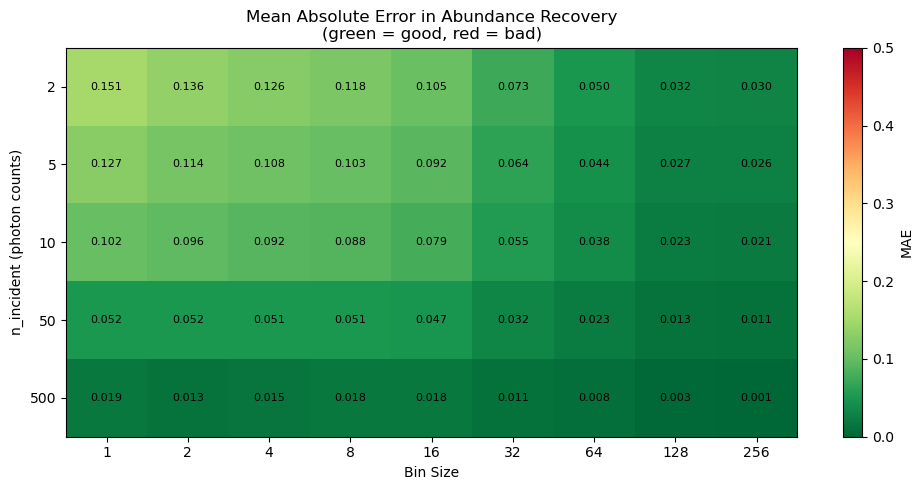


 n_inc | bin=1   | bin=2   | bin=4   | bin=8   | bin=16  | bin=32  | bin=64  | bin=128 | bin=256
----------------------------------------------------------------------------------------------------
     2 | 0.151   | 0.136   | 0.126   | 0.118   | 0.105   | 0.073   | 0.050   | 0.032   | 0.030  
     5 | 0.127   | 0.114   | 0.108   | 0.103   | 0.092   | 0.064   | 0.044   | 0.027   | 0.026  
    10 | 0.102   | 0.096   | 0.092   | 0.088   | 0.079   | 0.055   | 0.038   | 0.023   | 0.021  
    50 | 0.052   | 0.052   | 0.051   | 0.051   | 0.047   | 0.032   | 0.023   | 0.013   | 0.011  
   500 | 0.019   | 0.013   | 0.015   | 0.018   | 0.018   | 0.011   | 0.008   | 0.003   | 0.001  


In [8]:
# --- Visualize the binning sweep as a heatmap ---
mae_matrix = np.full((len(noise_levels), len(bin_sizes)), np.nan)
for i, n_inc in enumerate(noise_levels):
    for j, bs in enumerate(bin_sizes):
        key = (n_inc, bs)
        if key in results_sweep:
            avg_mae = (results_sweep[key]["u235_mae"] + results_sweep[key]["pu241_mae"]) / 2
            mae_matrix[i, j] = avg_mae

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mae_matrix, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=0.5)
ax.set_xticks(range(len(bin_sizes)))
ax.set_xticklabels([str(b) for b in bin_sizes])
ax.set_yticks(range(len(noise_levels)))
ax.set_yticklabels([str(n) for n in noise_levels])
ax.set_xlabel("Bin Size")
ax.set_ylabel("n_incident (photon counts)")
ax.set_title("Mean Absolute Error in Abundance Recovery\n(green = good, red = bad)")
fig.colorbar(im, ax=ax, label="MAE")

# Annotate cells with values
for i in range(len(noise_levels)):
    for j in range(len(bin_sizes)):
        val = mae_matrix[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.25 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8, color=color)

fig.tight_layout()
save_fig(fig, "01_binning_sweep_heatmap")

# Print table
print(f"\n{'n_inc':>6} | " + " | ".join(f"bin={b:<3}" for b in bin_sizes))
print("-" * (10 + 10 * len(bin_sizes)))
for i, n_inc in enumerate(noise_levels):
    row = []
    for j, bs in enumerate(bin_sizes):
        val = mae_matrix[i, j]
        row.append(f"{val:.3f}" if not np.isnan(val) else "  N/A")
    print(f"{n_inc:>6} | " + " | ".join(f"{r:<7}" for r in row))

In [9]:
# --- GATE CHECK: Point detector (full collapse) ---
# If bin_size=256 (single pixel = entire detector averaged) cannot recover
# the correct abundances, our noise model is fundamentally broken.

print("=" * 60)
print("GATE CHECK: Point Detector Recovery")
print("=" * 60)

gate_passed = True
for n_inc in noise_levels:
    key = (n_inc, 256)
    if key not in results_sweep:
        print(f"  n_incident={n_inc}: MISSING (no data)")
        gate_passed = False
        continue

    r = results_sweep[key]
    avg_mae = (r["u235_mae"] + r["pu241_mae"]) / 2
    status = "PASS" if avg_mae < 0.1 else "FAIL"
    if status == "FAIL":
        gate_passed = False
    print(f"  n_incident={n_inc:>4}: U235 MAE={r['u235_mae']:.4f}, "
          f"Pu241 MAE={r['pu241_mae']:.4f}, avg={avg_mae:.4f} [{status}]")

print()
if gate_passed:
    print("GATE PASSED: Point detector recovers correct abundances at all noise levels.")
    print("Noise model is valid. Proceeding to Stage 2.")
else:
    print("GATE FAILED: Point detector cannot recover abundances.")
    print("STOP: Fix the noise model before proceeding.")

GATE CHECK: Point Detector Recovery
  n_incident=   2: U235 MAE=0.0301, Pu241 MAE=0.0301, avg=0.0301 [PASS]
  n_incident=   5: U235 MAE=0.0257, Pu241 MAE=0.0257, avg=0.0257 [PASS]
  n_incident=  10: U235 MAE=0.0212, Pu241 MAE=0.0212, avg=0.0212 [PASS]
  n_incident=  50: U235 MAE=0.0105, Pu241 MAE=0.0105, avg=0.0105 [PASS]
  n_incident= 500: U235 MAE=0.0012, Pu241 MAE=0.0012, avg=0.0012 [PASS]

GATE PASSED: Point detector recovers correct abundances at all noise levels.
Noise model is valid. Proceeding to Stage 2.


---

# Stage 2: Baseline -- SAMMY Fitting on Noisy Data

**Question**: Can SAMMY's full R-matrix nonlinear fitting absorb the noise on its own,
without any preprocessing?

**Method**: Run per-pixel SAMMY fitting with stride=16 over the full 256x256 image
(256 pixels, ~30s per run). This produces a low-resolution 16x16 abundance map that
covers both isotope logos, letting us see whether SAMMY can still separate U-235 from
Pu-241 spatially when the input spectra are noisy.

We test clean data (baseline), moderate noise (n=10), and heavy noise (n=2).


SAMMY on clean data (stride=16)...


2026-02-23 11:23:23 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 256 success, 0 failed


  Done in 261s, 256 pixels OK


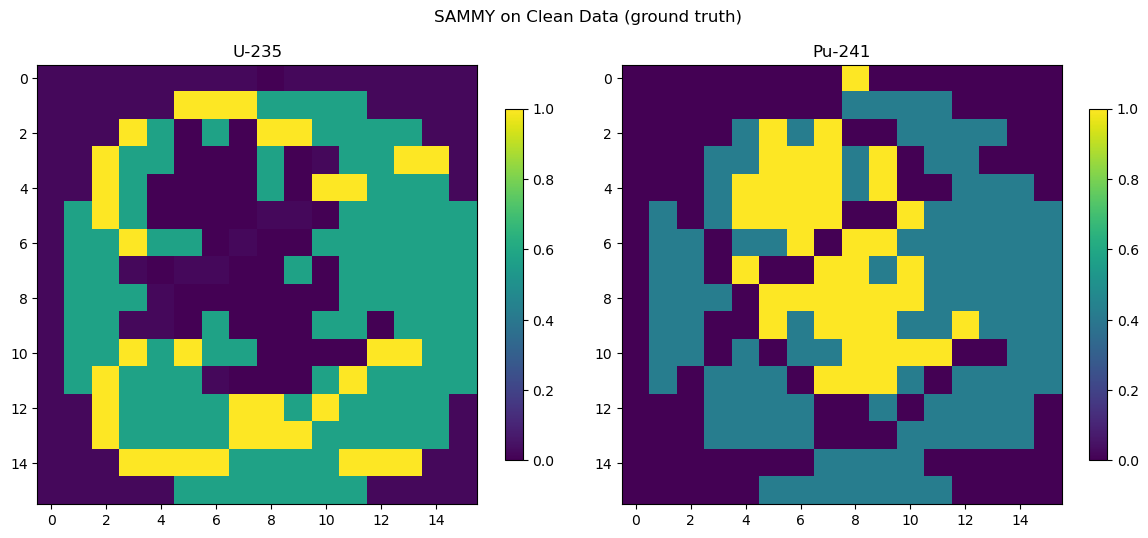

In [10]:
# --- SAMMY fitting: clean baseline ---
print("SAMMY on clean data (stride=16)...")
t0 = time.time()
results_sammy_clean = run_sammy_strided(hyperspectral.data)
print(f"  Done in {time.time()-t0:.0f}s, {results_sammy_clean.success_mask.sum()} pixels OK")

fig = plot_abundance_maps(results_sammy_clean, "SAMMY on Clean Data (ground truth)")
save_fig(fig, "02_sammy_clean_maps")



SAMMY on noisy data (n_incident=10, stride=16)...


2026-02-23 11:27:46 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:743 - Retry round 1/1: 19 pixels to retry


2026-02-23 11:28:06 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 237 success, 19 failed


  Done in 283s, 237 pixels OK


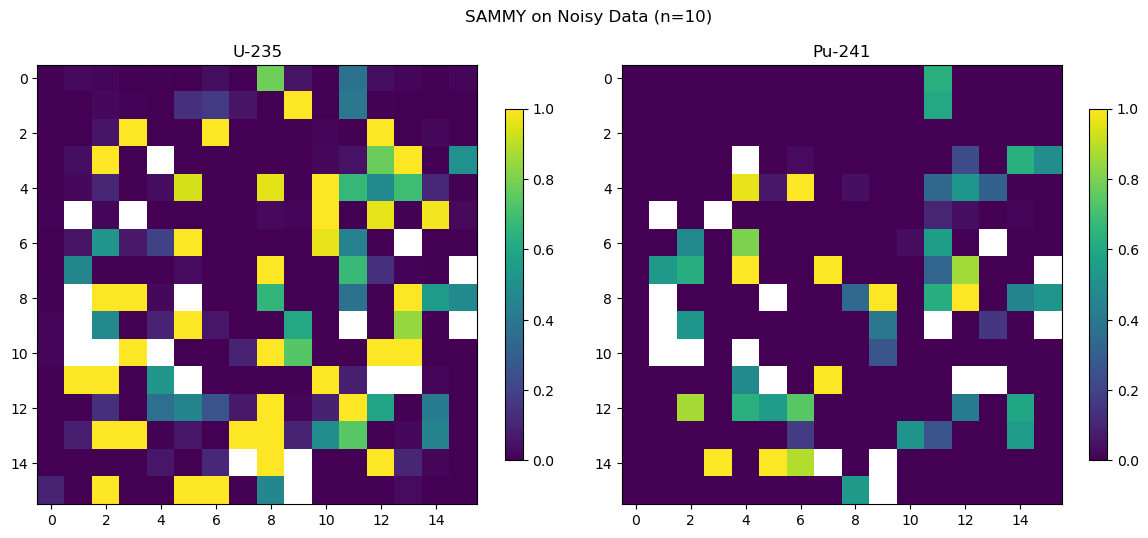

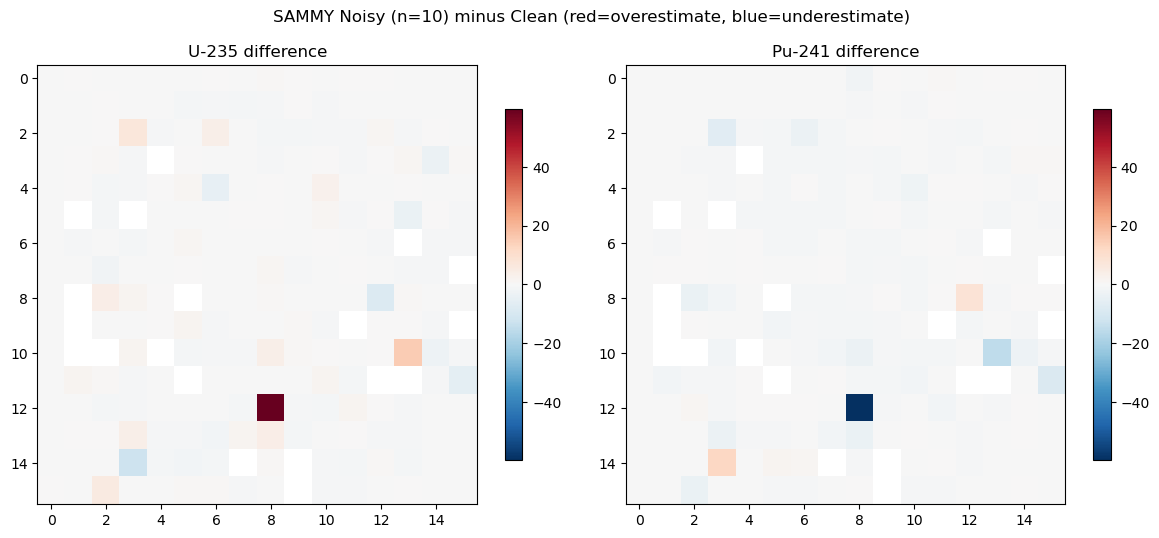


SAMMY on noisy data (n_incident=2, stride=16)...


2026-02-23 11:32:34 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 256 success, 0 failed


  Done in 267s, 256 pixels OK


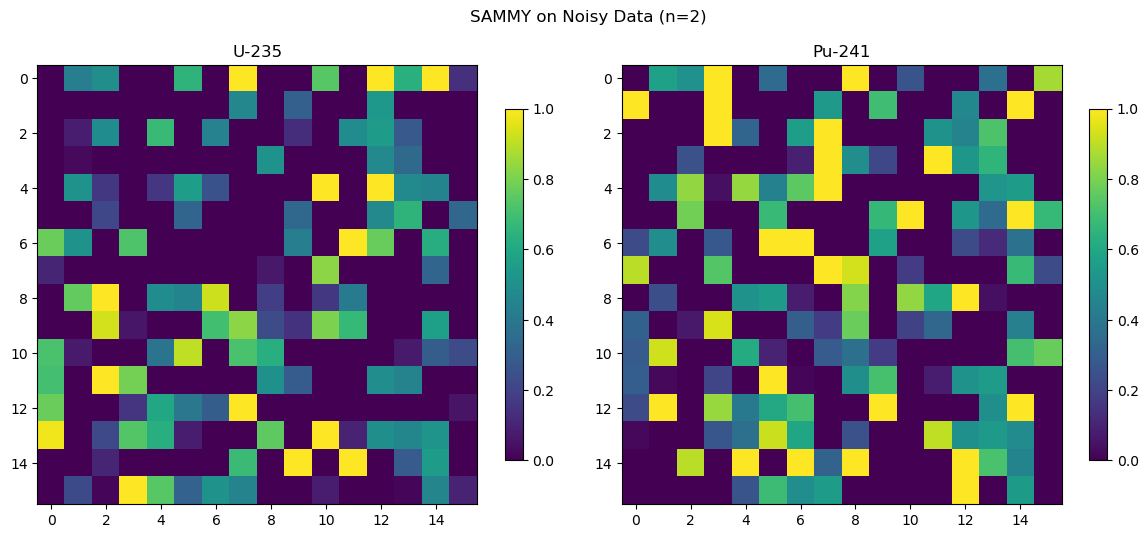

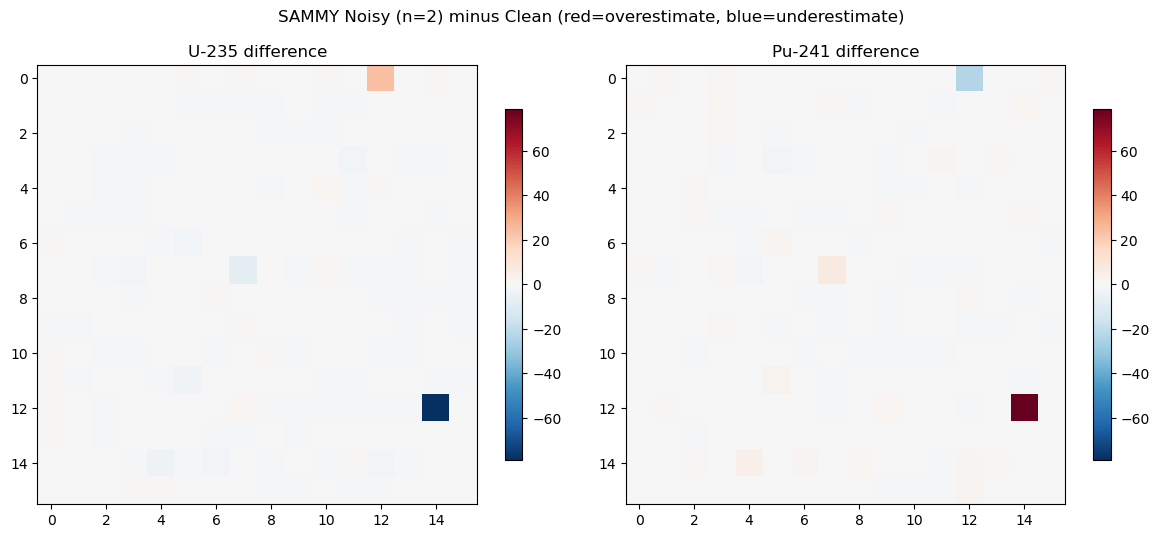

In [11]:
# --- SAMMY fitting: noisy data at n=10 and n=2 ---
sammy_noisy_results = {}
for n_inc in [10, 2]:
    print(f"\nSAMMY on noisy data (n_incident={n_inc}, stride={SAMMY_STRIDE})...")
    t0 = time.time()
    result = run_sammy_strided(noisy_data[n_inc])
    elapsed = time.time() - t0
    n_ok = result.success_mask.sum()
    print(f"  Done in {elapsed:.0f}s, {n_ok} pixels OK")
    sammy_noisy_results[n_inc] = result

    # Abundance maps
    fig = plot_abundance_maps(result, f"SAMMY on Noisy Data (n={n_inc})")
    save_fig(fig, f"02_sammy_noisy_n{n_inc}_maps")

    # Difference vs clean
    fig = plot_difference_maps(result, results_sammy_clean,
                               f"SAMMY Noisy (n={n_inc}) minus Clean")
    save_fig(fig, f"02_sammy_noisy_n{n_inc}_diff")


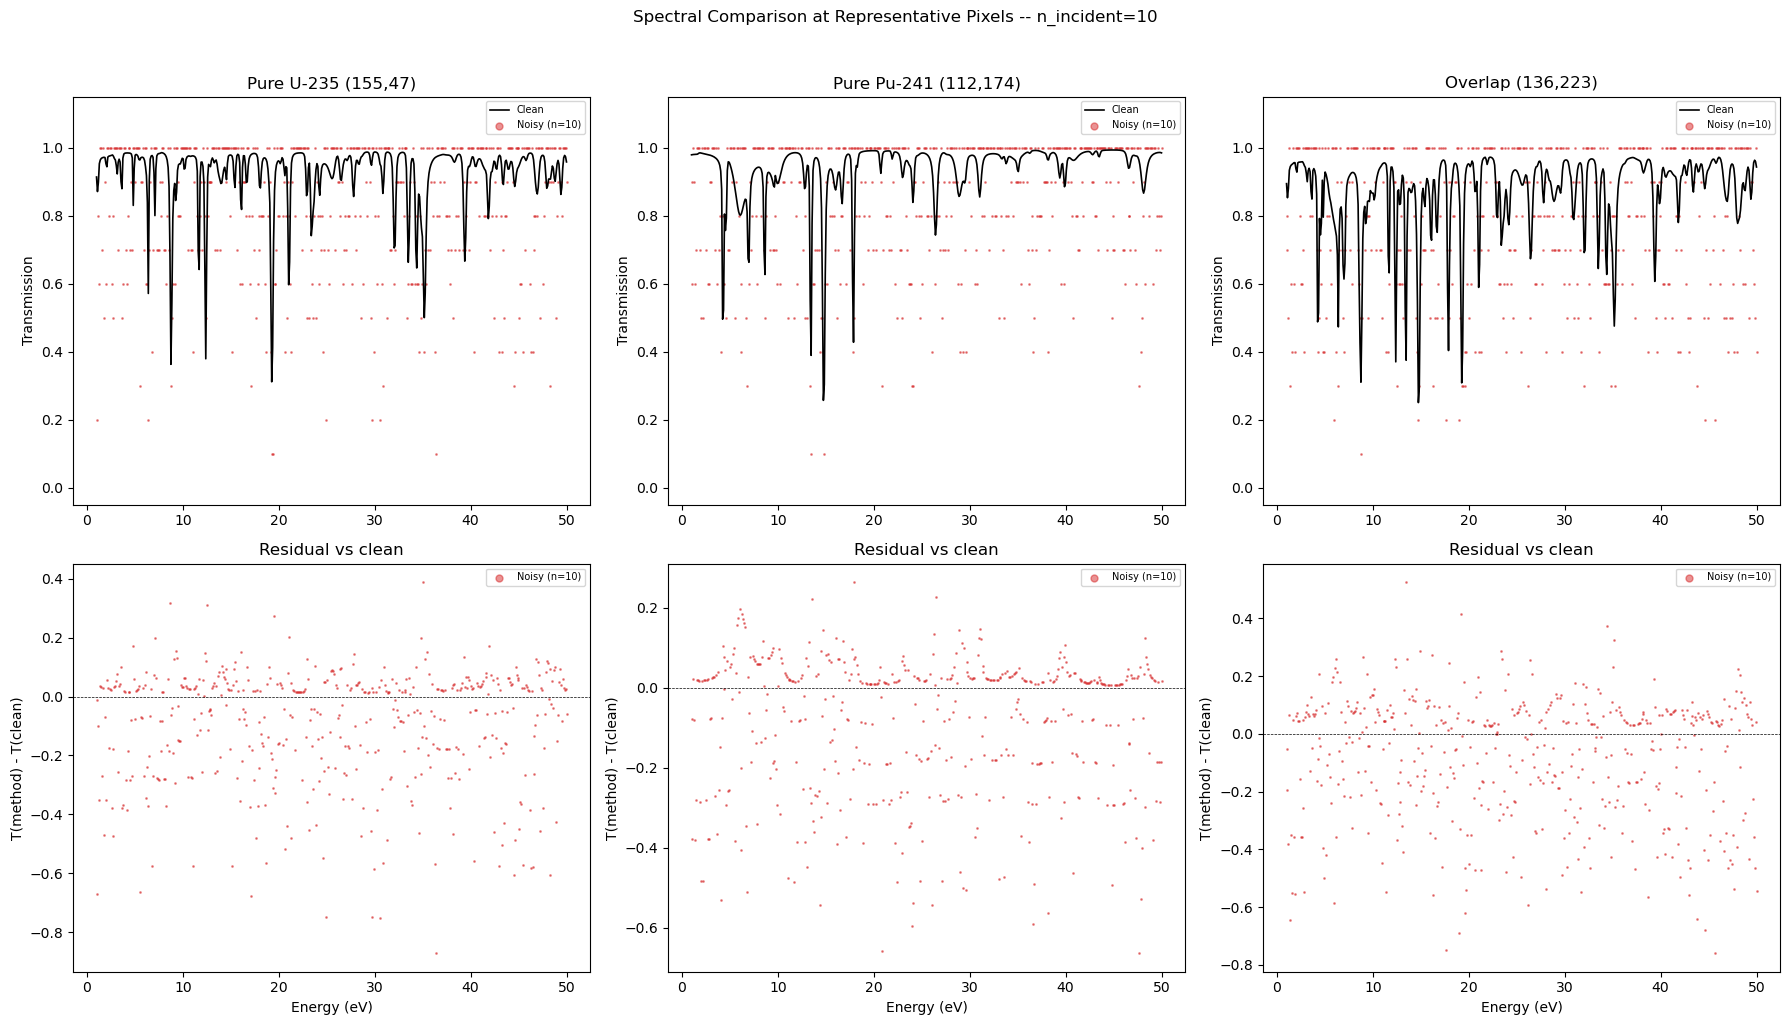

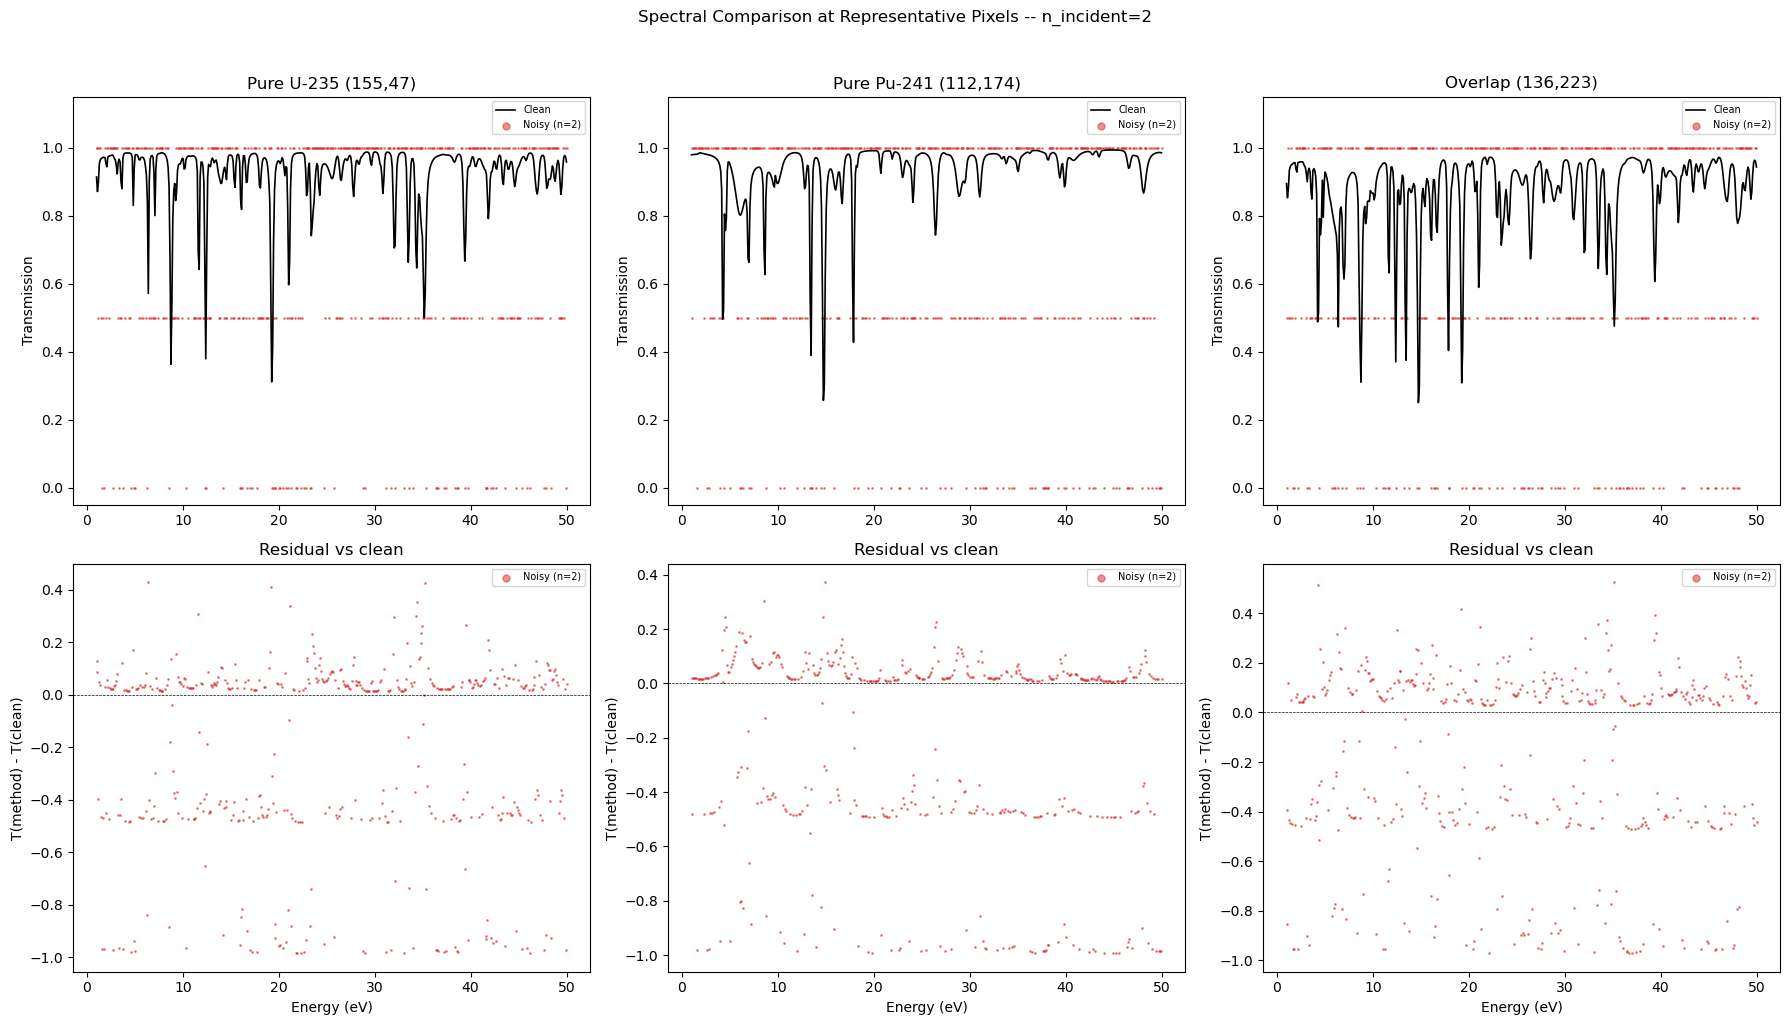

In [12]:
# --- Spectral view: what does SAMMY see at each representative pixel? ---
# Show the raw input spectra (clean vs noisy) at the 3 representative pixels
for n_inc in [10, 2]:
    fig = plot_spectra_at_pixels(
        [hyperspectral.data, noisy_data[n_inc]],
        ["Clean", f"Noisy (n={n_inc})"],
        title_suffix=f" -- n_incident={n_inc}",
    )
    save_fig(fig, f"02_spectra_noisy_n{n_inc}")


### Stage 2 Observations

Examine the abundance maps and difference images above:
- **Clean SAMMY maps**: Do the two logos (ORNL oak leaf for U-235, LANL atom for Pu-241)
  appear clearly separated?
- **Noisy SAMMY maps**: Do the logos degrade? Is one isotope affected more than the other?
- **Difference images**: Where does SAMMY fail most -- in the pure zones, overlap, or background?
- **Spectral plots**: How much does noise distort the resonance features at each pixel type?


---

# Stage 3: Traditional Denoising + SAMMY Fitting

**Question**: Can standard spectral-domain filters (median, Savitzky-Golay, moving average)
clean up noisy spectra enough for SAMMY to converge better?

**Method**:
1. Apply each filter to the noisy data (per-pixel, spectral axis only)
2. Show what each filter does to the spectrum at representative pixels
3. Feed the filtered data to SAMMY (stride=16) and compare maps
4. Also run NNLS on filtered data for a fast full-image comparison

**Key limitation to watch for**: Per-pixel spectral filters have no spatial context.
They treat each pixel independently and cannot exploit the fact that neighboring pixels
share similar spectral features.


In [13]:
# --- Denoising functions ---
def denoise_median(data, kernel_size=5):
    """Median filter along the spectral (energy) axis per pixel."""
    result = np.empty_like(data)
    for r in range(data.shape[1]):
        for c in range(data.shape[2]):
            result[:, r, c] = median_filter(data[:, r, c], size=kernel_size)
    return np.clip(result, 0, 1)

def denoise_savgol(data, window_length=11, polyorder=2):
    """Savitzky-Golay filter along the spectral axis per pixel."""
    result = np.empty_like(data)
    for r in range(data.shape[1]):
        for c in range(data.shape[2]):
            result[:, r, c] = savgol_filter(data[:, r, c], window_length, polyorder)
    return np.clip(result, 0, 1)

def denoise_moving_average(data, window_size=5):
    """Moving average along the spectral axis per pixel."""
    kernel = np.ones(window_size) / window_size
    result = np.empty_like(data)
    for r in range(data.shape[1]):
        for c in range(data.shape[2]):
            result[:, r, c] = np.convolve(data[:, r, c], kernel, mode="same")
    return np.clip(result, 0, 1)

print("Denoising functions defined.")


Denoising functions defined.


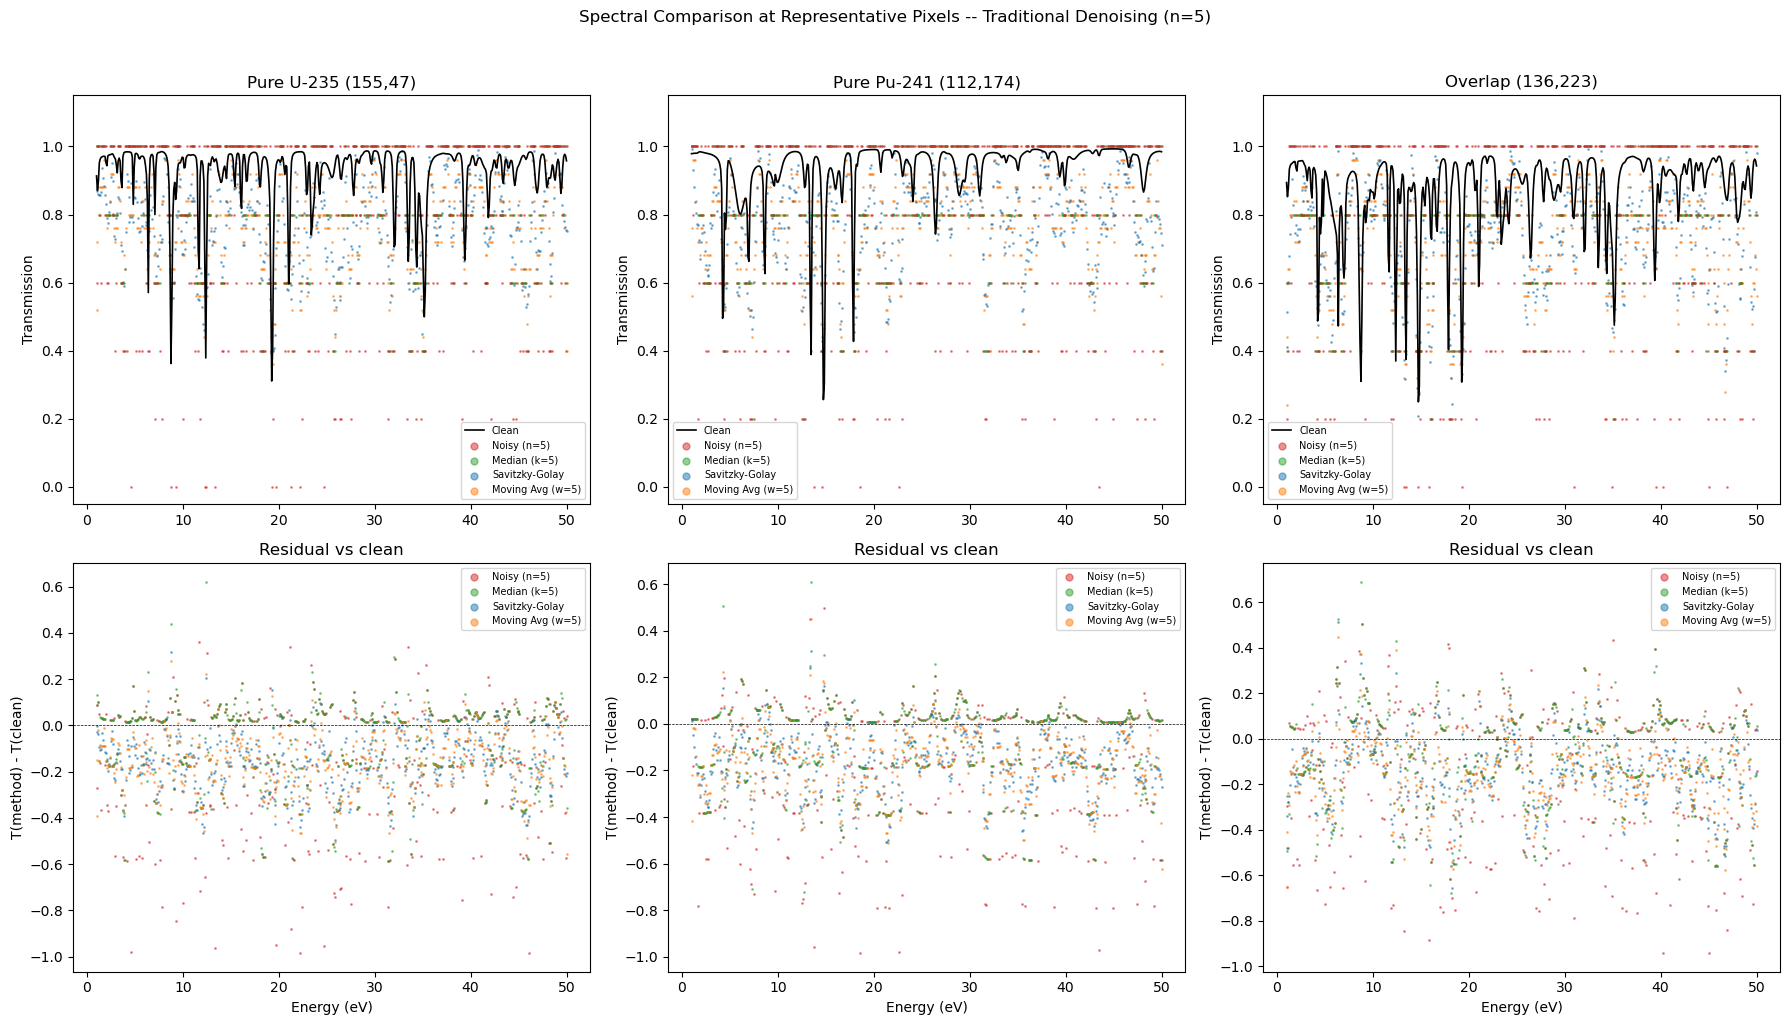

In [14]:
# --- Spectral comparison: what do filters do to the spectrum? ---
# For n_incident=5 (moderate noise), show each filter's effect at representative pixels.

n_inc = 5
data_noisy = noisy_data[n_inc]
data_median = denoise_median(data_noisy, kernel_size=5)
data_savgol = denoise_savgol(data_noisy, window_length=11, polyorder=2)
data_movavg = denoise_moving_average(data_noisy, window_size=5)

fig = plot_spectra_at_pixels(
    [hyperspectral.data, data_noisy, data_median, data_savgol, data_movavg],
    ["Clean", f"Noisy (n={n_inc})", "Median (k=5)", "Savitzky-Golay", "Moving Avg (w=5)"],
    title_suffix=f" -- Traditional Denoising (n={n_inc})",
)
save_fig(fig, "03_denoising_spectra")



SAMMY on SG-denoised data (n_incident=10)...


2026-02-23 11:37:32 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 256 success, 0 failed


  Done in 274s, 256 pixels OK


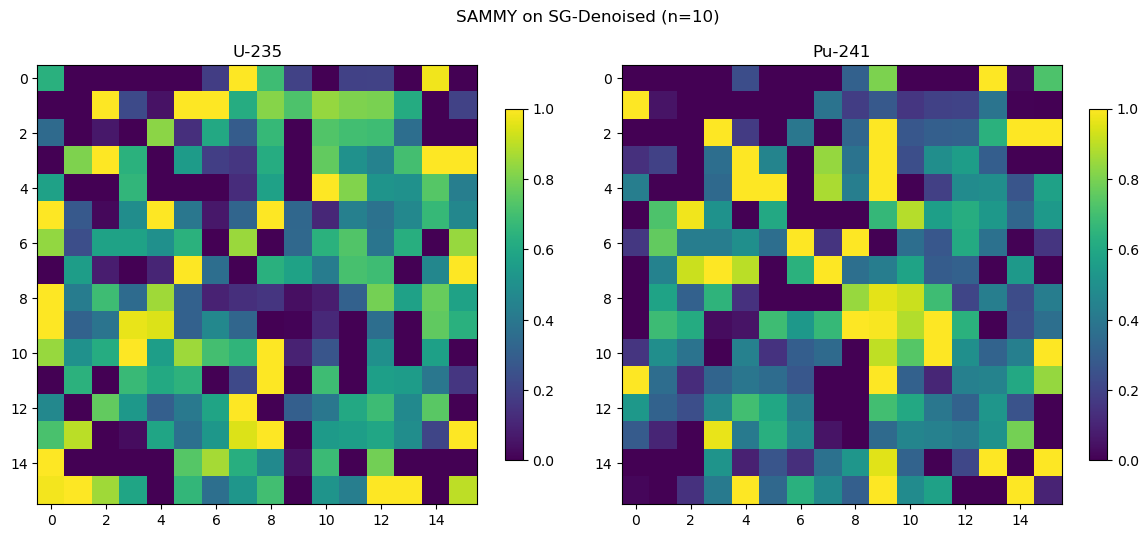

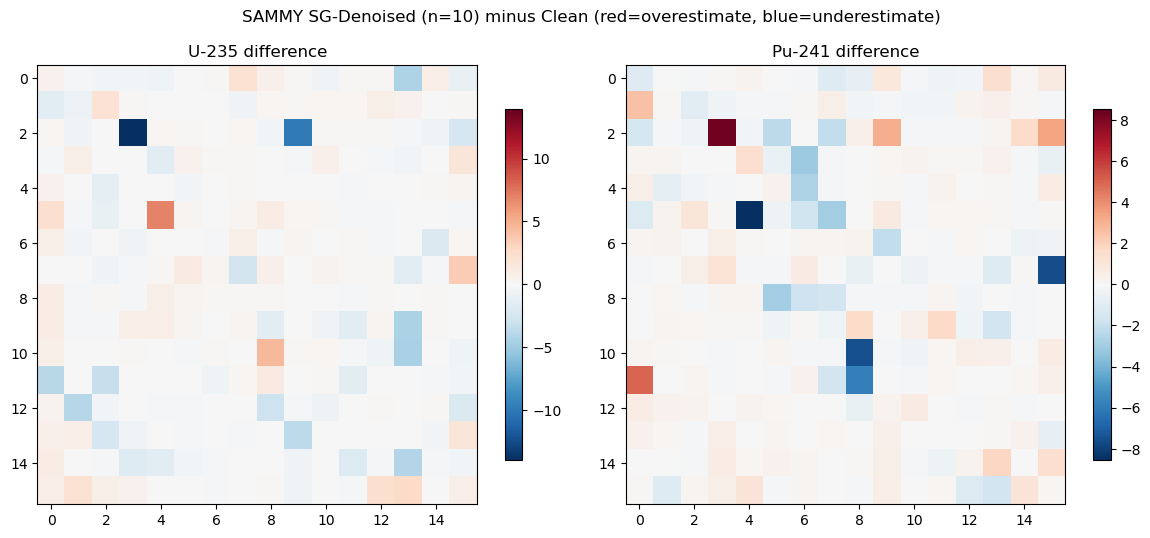


SAMMY on SG-denoised data (n_incident=2)...


2026-02-23 11:42:11 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:743 - Retry round 1/1: 1 pixels to retry


2026-02-23 11:42:22 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 255 success, 1 failed


  Done in 279s, 255 pixels OK


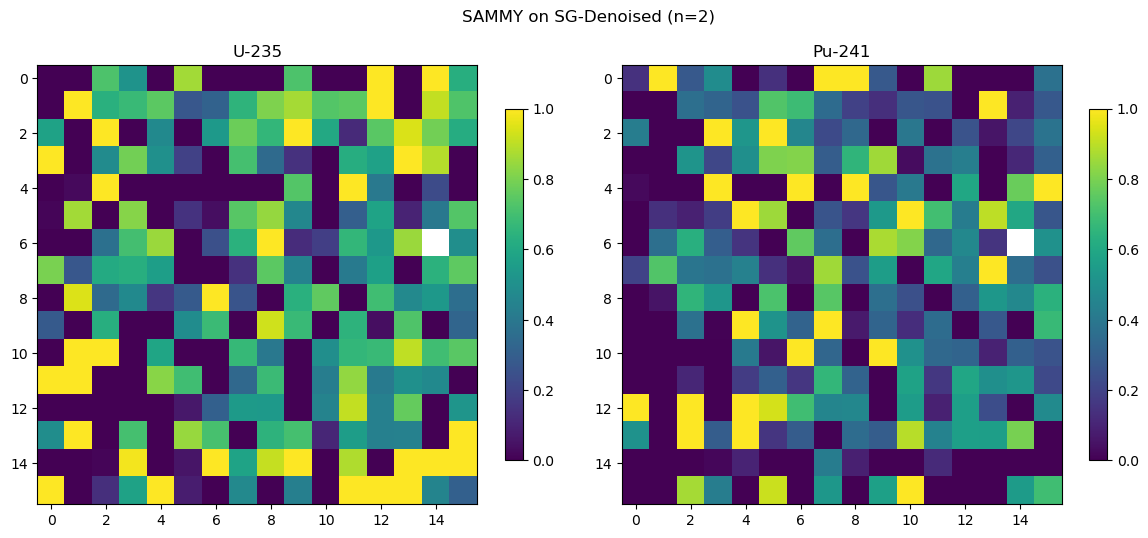

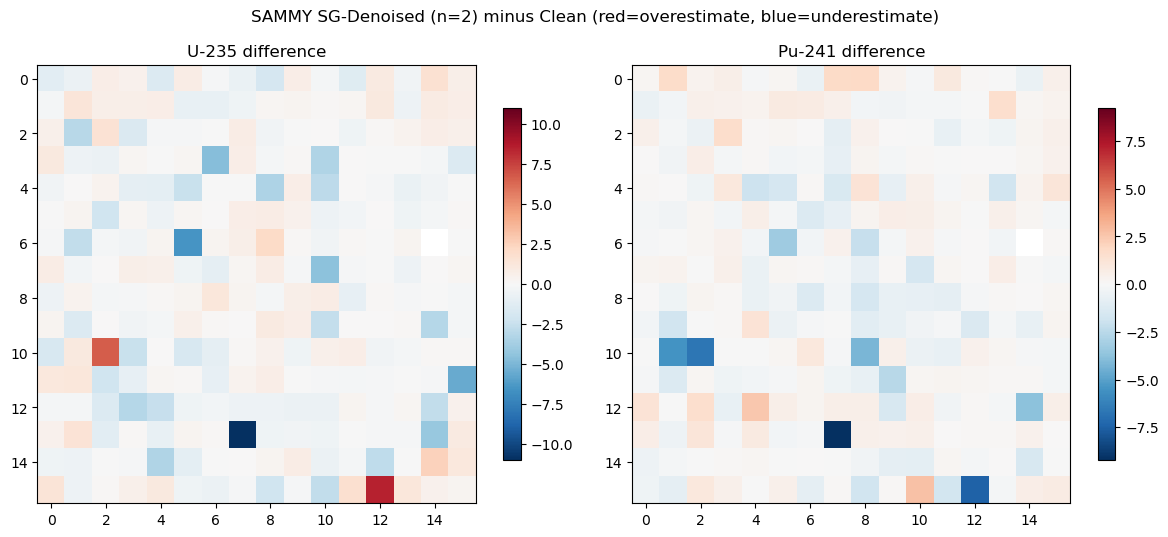

In [15]:
# --- SAMMY on Savitzky-Golay denoised data ---
# SG is typical for spectral data. Run SAMMY on denoised data and compare.

sammy_denoised_results = {}
for n_inc in [10, 2]:
    print(f"\nSAMMY on SG-denoised data (n_incident={n_inc})...")
    data_sg = denoise_savgol(noisy_data[n_inc], window_length=11, polyorder=2)
    t0 = time.time()
    result = run_sammy_strided(data_sg)
    elapsed = time.time() - t0
    n_ok = result.success_mask.sum()
    print(f"  Done in {elapsed:.0f}s, {n_ok} pixels OK")
    sammy_denoised_results[n_inc] = result

    # Abundance maps
    fig = plot_abundance_maps(result, f"SAMMY on SG-Denoised (n={n_inc})")
    save_fig(fig, f"03_sammy_sg_n{n_inc}_maps")

    # Difference vs clean SAMMY
    fig = plot_difference_maps(result, results_sammy_clean,
                               f"SAMMY SG-Denoised (n={n_inc}) minus Clean")
    save_fig(fig, f"03_sammy_sg_n{n_inc}_diff")


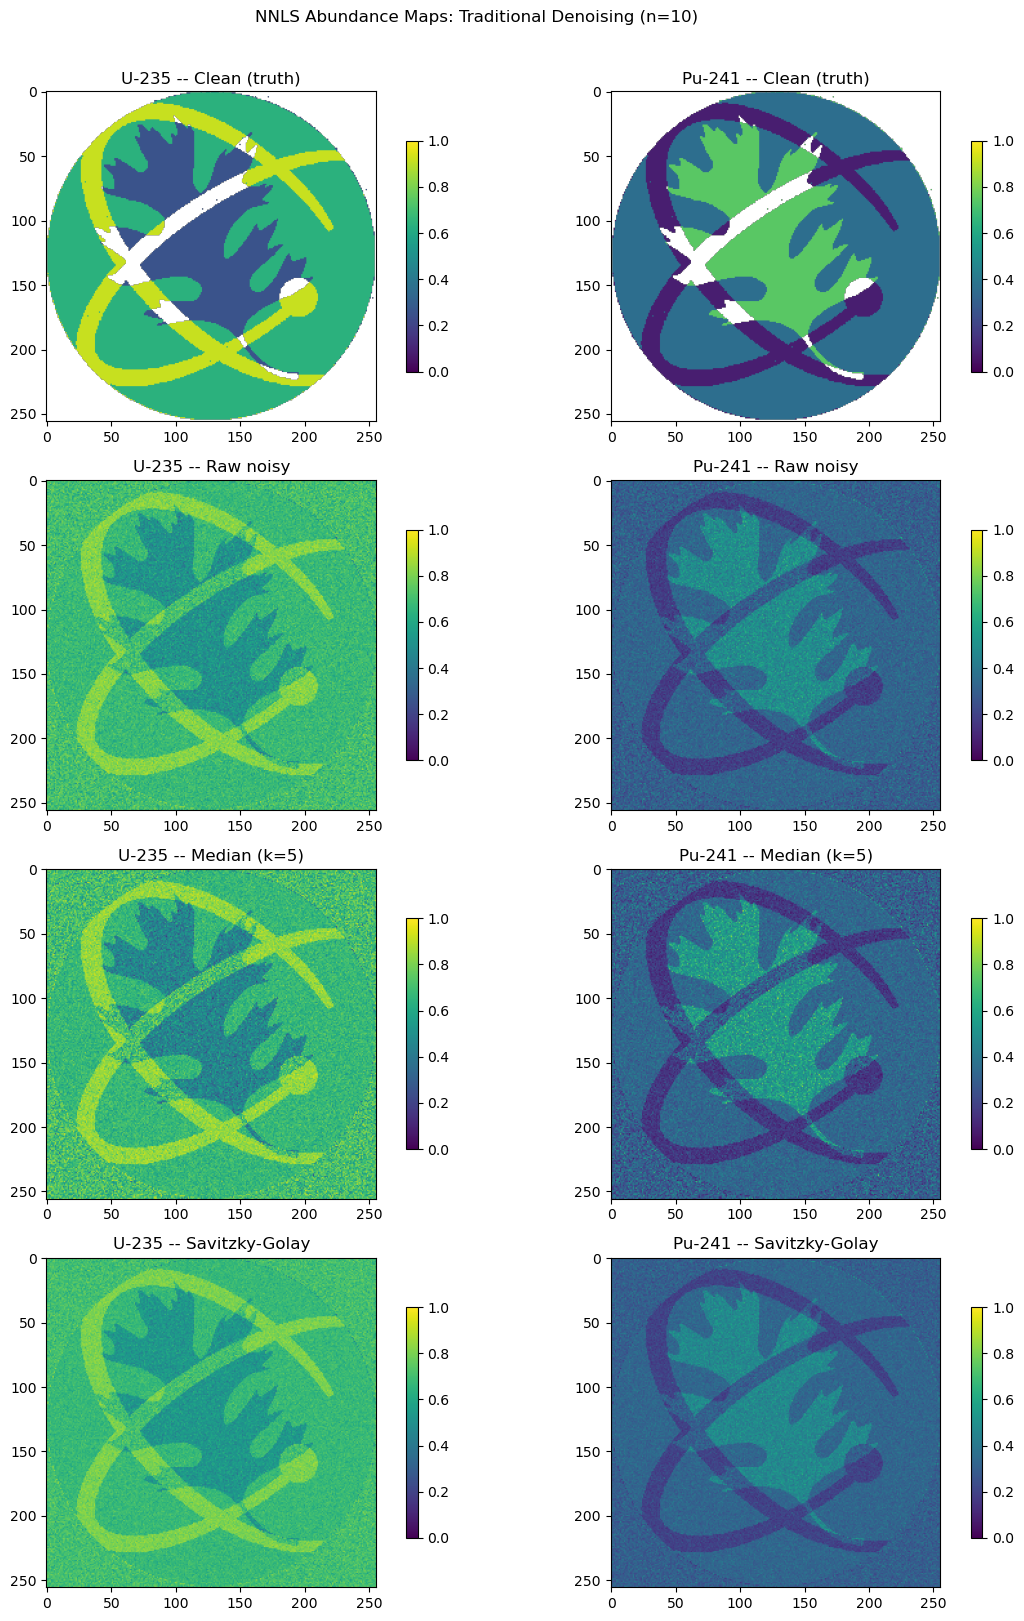

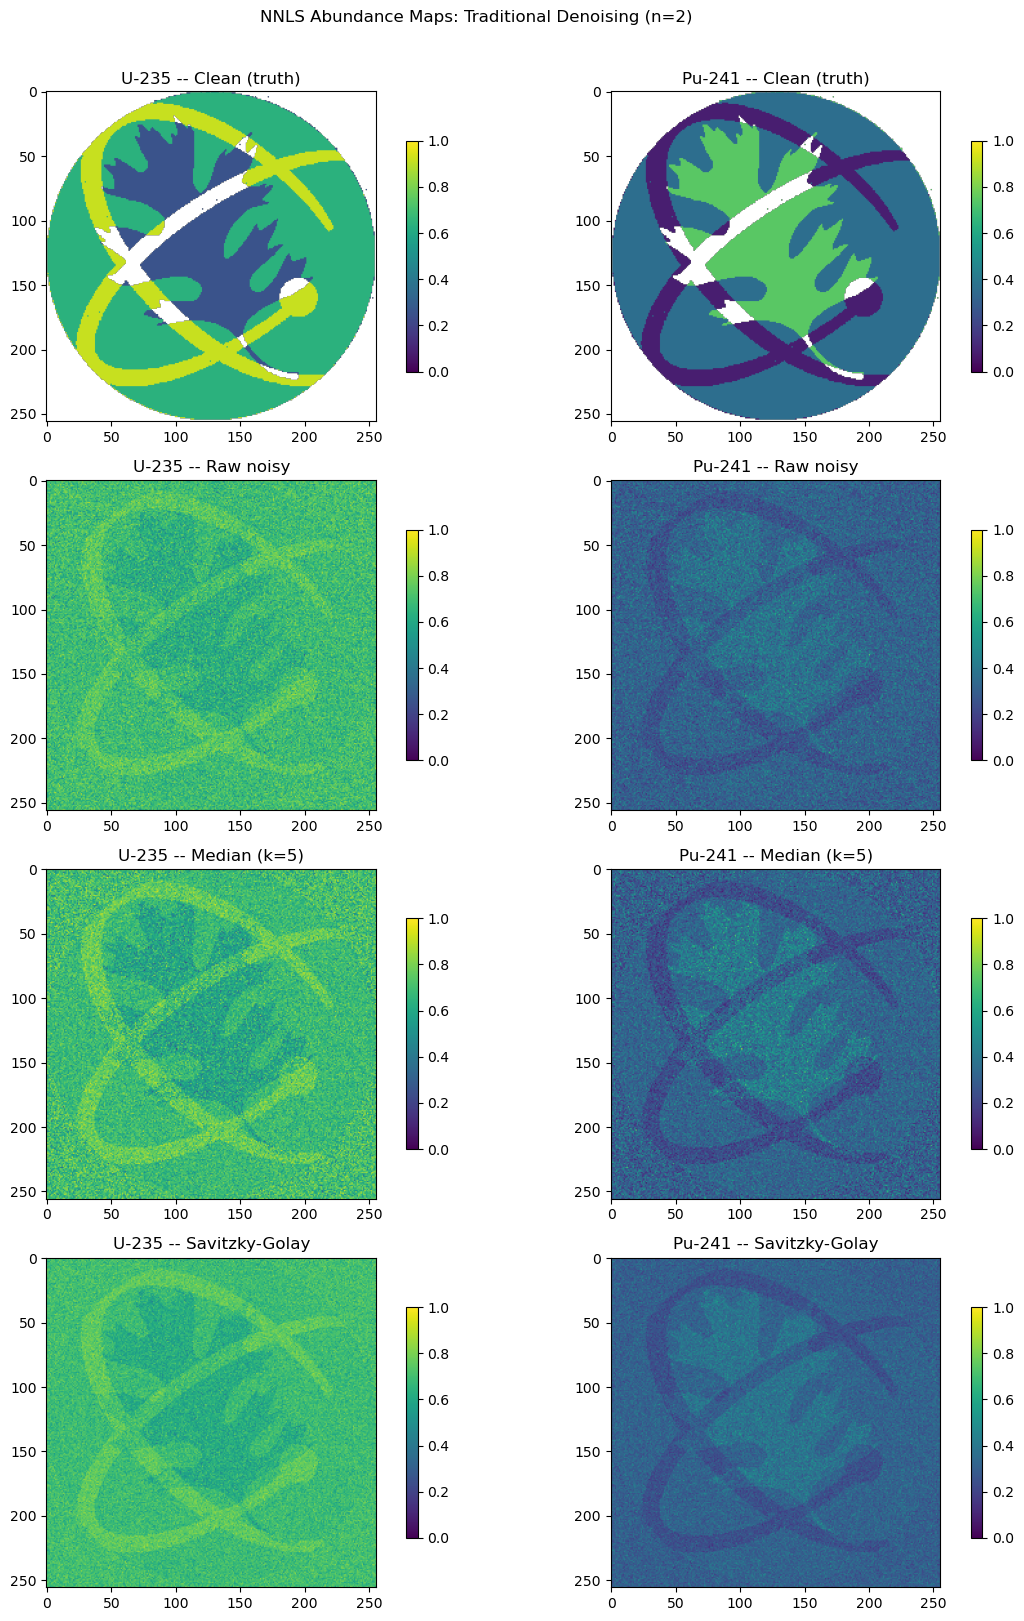

In [16]:
# --- NNLS full-image comparison (fast) ---
# Run NNLS on raw noisy and each denoised version for full-image maps.

for n_inc in [10, 2]:
    data_n = noisy_data[n_inc]
    data_sg = denoise_savgol(data_n, window_length=11, polyorder=2)
    data_med = denoise_median(data_n, kernel_size=5)

    methods = {
        "Raw noisy": data_n,
        "Median (k=5)": data_med,
        "Savitzky-Golay": data_sg,
    }

    fig, axes = plt.subplots(len(methods) + 1, 2, figsize=(12, 4 * (len(methods) + 1)))

    # Ground truth (clean) in first row
    for i, iso in enumerate(config.isotopes):
        im = axes[0, i].imshow(results_clean.abundance_maps[i], cmap="viridis",
                                origin="upper", vmin=0, vmax=1)
        axes[0, i].set_title(f"{iso} -- Clean (truth)")
        fig.colorbar(im, ax=axes[0, i], shrink=0.7)

    for row, (mname, data) in enumerate(methods.items(), 1):
        hs_d = type(hyperspectral)(
            data=data, energy=energy,
            uncertainty=np.maximum(0.02 * np.abs(data) + 1e-4, 1e-4).astype(np.float32),
            source_file=hyperspectral.source_file,
        )
        result = recovery.recover_image(hs_d, reference_spectra=ref_spectra)
        for i, iso in enumerate(config.isotopes):
            im = axes[row, i].imshow(result.abundance_maps[i], cmap="viridis",
                                      origin="upper", vmin=0, vmax=1)
            axes[row, i].set_title(f"{iso} -- {mname}")
            fig.colorbar(im, ax=axes[row, i], shrink=0.7)

    fig.suptitle(f"NNLS Abundance Maps: Traditional Denoising (n={n_inc})", y=1.01)
    fig.tight_layout()
    save_fig(fig, f"03_nnls_denoised_n{n_inc}_maps")


### Stage 3 Observations

Examine the maps and spectra above:
- **Spectral residuals**: Do the filters smooth out noise without distorting resonance peaks?
  Or do they blur/shift the peaks (visible in the residual plots)?
- **SAMMY maps**: Does SG denoising produce clearer logo separation than raw noisy SAMMY?
- **NNLS maps**: Does denoising help NNLS recover cleaner spatial patterns at full resolution?
- **Compare SAMMY vs NNLS**: For the same preprocessed data, which fitting engine produces
  better spatial separation of the two isotopes?


---

# Stage 4: NMF-Based Approaches + SAMMY Fitting

**Question**: Can NMF-based preprocessing (which exploits spatial redundancy across 65K+
pixels) produce better input for SAMMY than per-pixel spectral filters?

**Three approaches**:
- **(a) Blind NMF decomposition**: Learn both spatial maps (W) and spectral basis (H)
  from data alone. We examine whether the learned basis matches SAMMY physics.
- **(b) Blind NMF as denoiser → SAMMY**: Reconstruct denoised spectra from the low-rank
  NMF approximation, then feed to SAMMY.
- **(c) Semi-NMF with SAMMY basis → SAMMY**: Fix H = SAMMY reference spectra, solve only
  for W via NNLS per pixel, reconstruct T = exp(-W*H), then feed to SAMMY. This is
  physics-informed preprocessing.

**Known limitation (clipping problem)**: All methods that convert to the attenuation domain
via `A = -ln(T)` require `T > 0`. With extreme noise (`n_incident=2`), many pixel-energy bins
have `T <= 0` (zero or negative counts). These get clipped to `T = 1e-6`, producing
`A = 13.8` — a huge artificial outlier that distorts both NMF basis learning and NNLS fits.
This is a fundamental fragility of working in the log domain with low-count data.
Real VENUS data will have the same issue: measured transmission can be 0, negative (after
background subtraction), or > 1 (normalization artifacts). Any robust recovery method must
handle these cases without clipping.


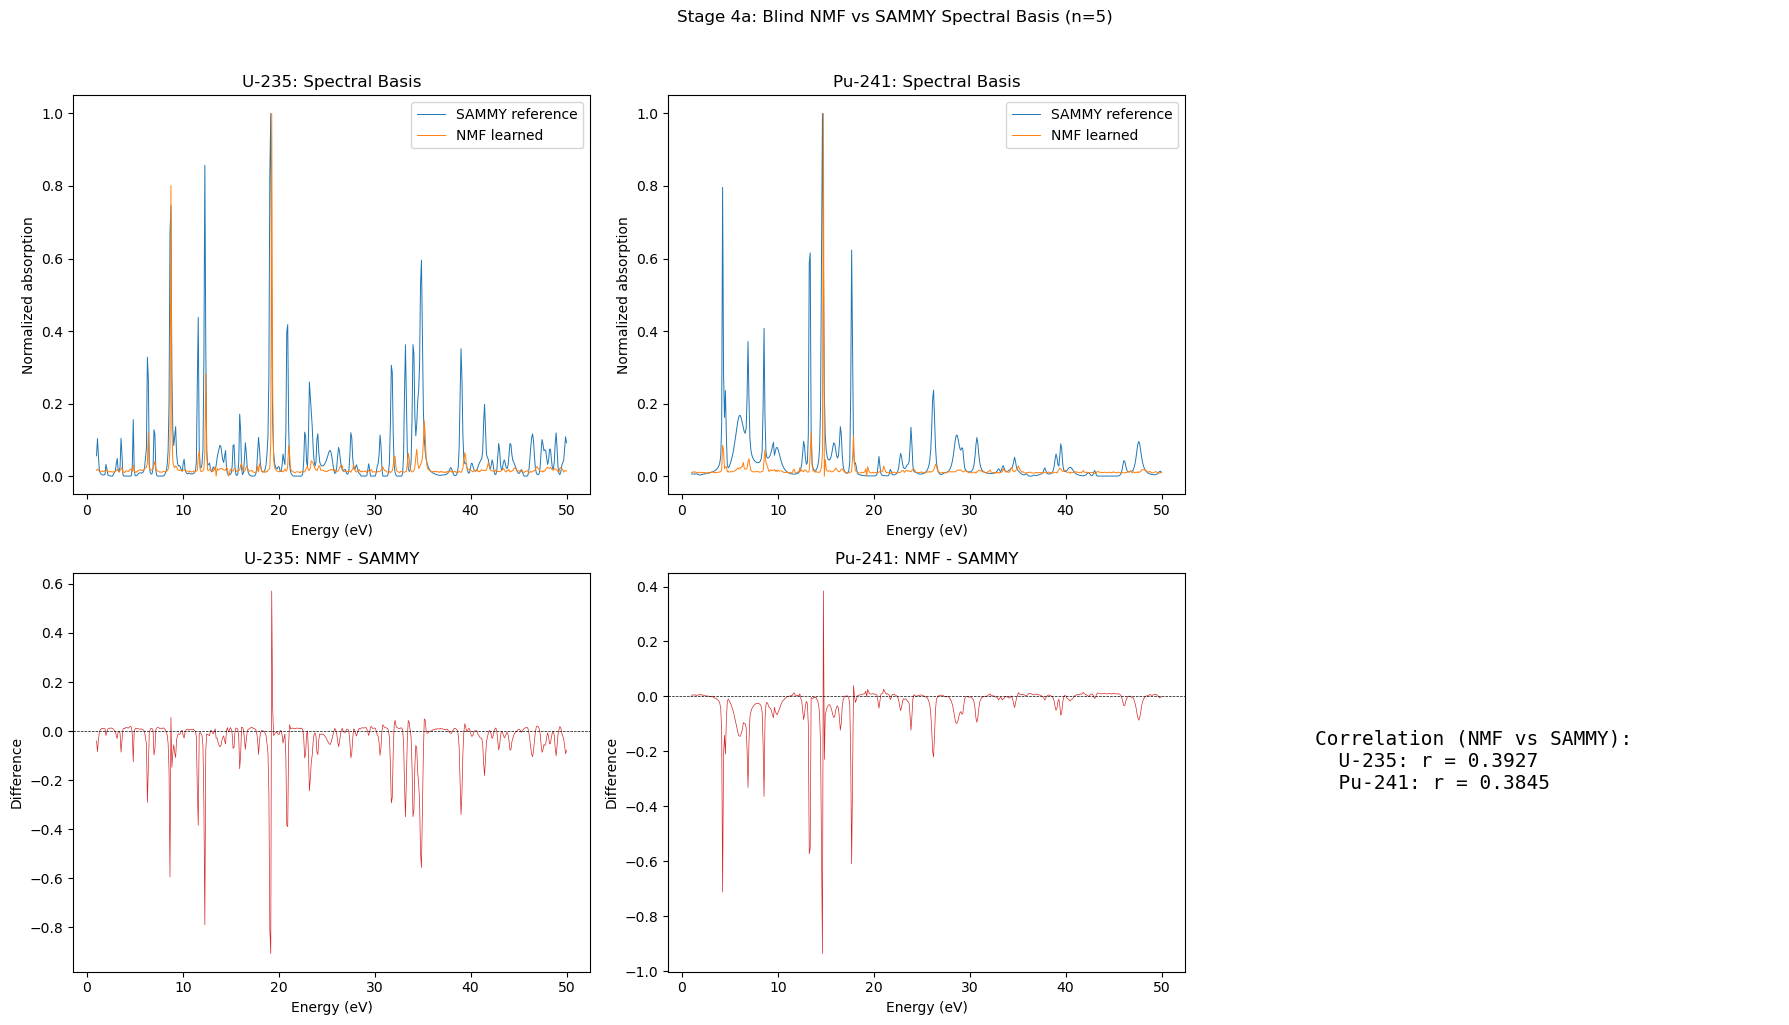

In [17]:
# --- Stage 4a: Blind NMF -- spectral basis mismatch ---
# NMF learns both W and H from data. We compare the learned H against
# the SAMMY forward-model reference spectra to see if they match.

n_inc = 5
hs_noisy = type(hyperspectral)(
    data=noisy_data[n_inc], energy=energy, source_file=hyperspectral.source_file,
)
# Use 4 components: 2 for signal (U-235, Pu-241) + 2 for noise/baseline
nmf = NMFRecovery(n_components=4, max_iter=200, random_state=42)
result_nmf = nmf.decompose(hs_noisy)
learned_basis = result_nmf.metadata["spectral_basis"]  # (n_components, n_energy)

# Use label_components to match NMF components to isotopes
result_nmf_labeled = NMFRecovery.label_components(result_nmf, ref_spectra)

# Plot: 2 rows x 2 cols
# Top row: SAMMY ref vs NMF learned (separate panels, same y-scale)
# Bottom row: difference (NMF - SAMMY) and NMF abundance maps
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Reorder learned_basis to match labeled order
labeled_basis = result_nmf_labeled.metadata.get("spectral_basis", learned_basis)

for i, ref in enumerate(ref_spectra):
    # Normalize for comparison
    ref_norm = ref.absorption / (ref.absorption.max() + 1e-10)
    nmf_norm = labeled_basis[i] / (labeled_basis[i].max() + 1e-10)

    # Top: side by side
    axes[0, i].plot(energy, ref_norm, lw=0.7, color="C0", label="SAMMY reference")
    axes[0, i].plot(energy, nmf_norm, lw=0.7, color="C1", label="NMF learned")
    axes[0, i].set_title(f"{ref.isotope_name}: Spectral Basis")
    axes[0, i].set_xlabel("Energy (eV)")
    axes[0, i].set_ylabel("Normalized absorption")
    axes[0, i].legend()

    # Bottom left/center: difference
    axes[1, i].plot(energy, nmf_norm - ref_norm, lw=0.5, color="C3")
    axes[1, i].axhline(0, color="black", lw=0.5, ls="--")
    axes[1, i].set_title(f"{ref.isotope_name}: NMF - SAMMY")
    axes[1, i].set_xlabel("Energy (eV)")
    axes[1, i].set_ylabel("Difference")

# Top right: NMF abundance maps
axes[0, 2].set_visible(False)

# Bottom right: correlation numbers
corr_text = "Correlation (NMF vs SAMMY):\n"
for i, ref in enumerate(ref_spectra):
    corr = np.corrcoef(labeled_basis[i], ref.absorption)[0, 1]
    corr_text += f"  {ref.isotope_name}: r = {corr:.4f}\n"
axes[1, 2].text(0.1, 0.5, corr_text, transform=axes[1, 2].transAxes,
                fontsize=14, verticalalignment="center", family="monospace")
axes[1, 2].set_axis_off()

fig.suptitle(f"Stage 4a: Blind NMF vs SAMMY Spectral Basis (n={n_inc})", y=1.02)
fig.tight_layout()
save_fig(fig, "04a_nmf_vs_sammy_basis")



NMF Denoising -> SAMMY (n_incident=10)


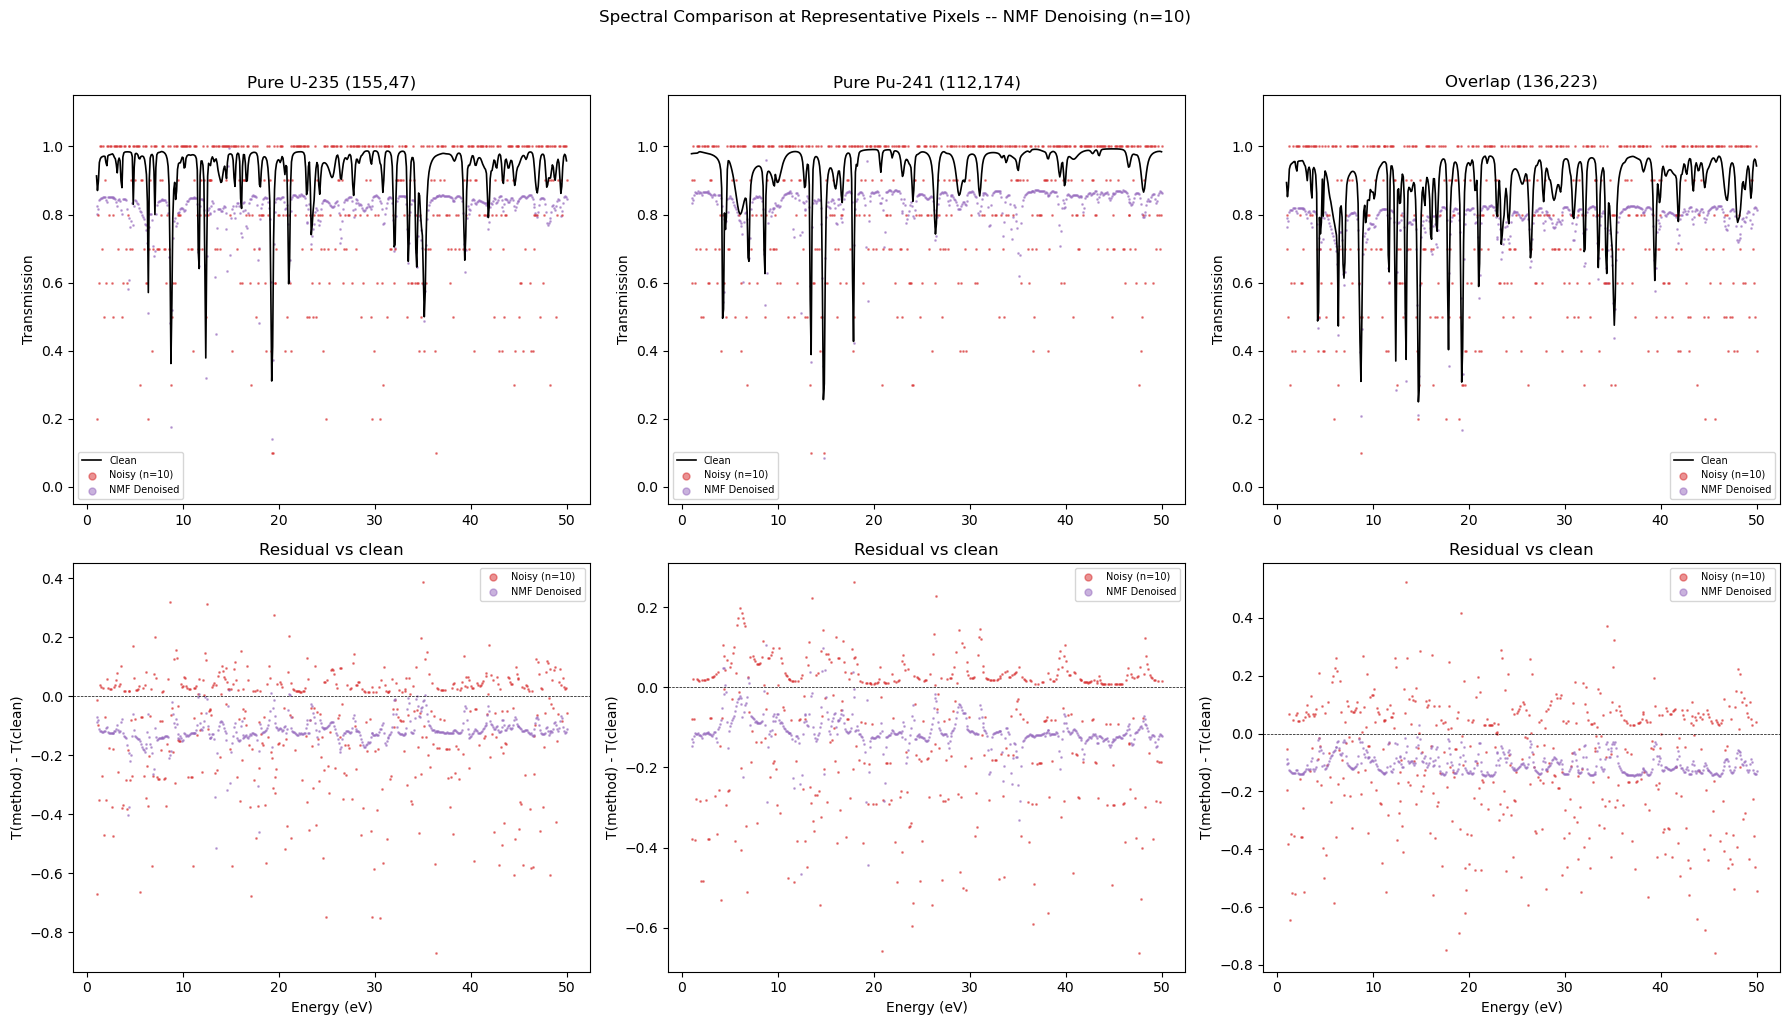

  Running SAMMY on NMF-denoised data...


2026-02-23 11:47:59 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 256 success, 0 failed


  Done in 272s, 256 pixels OK


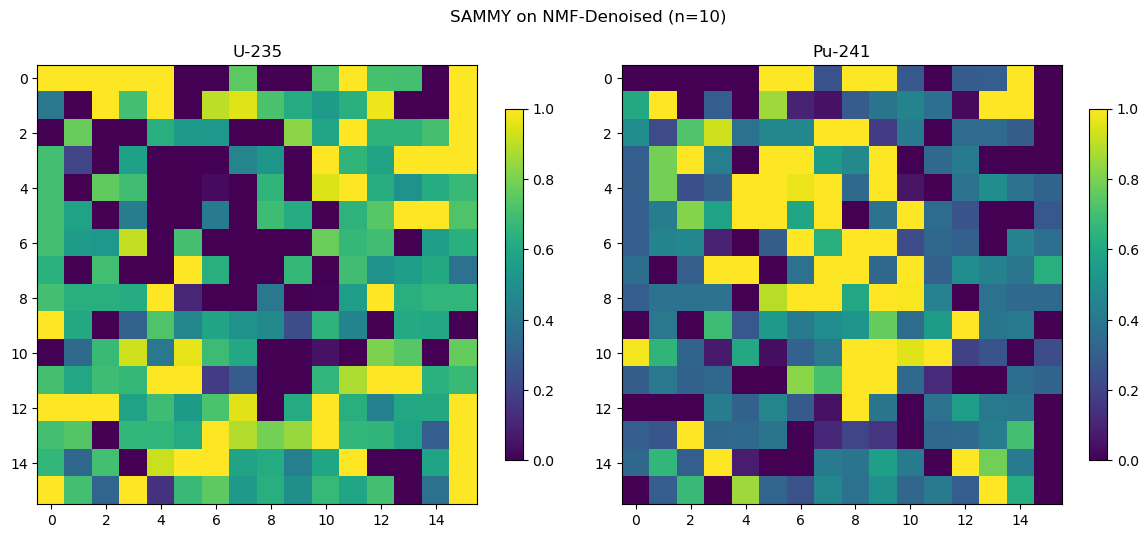

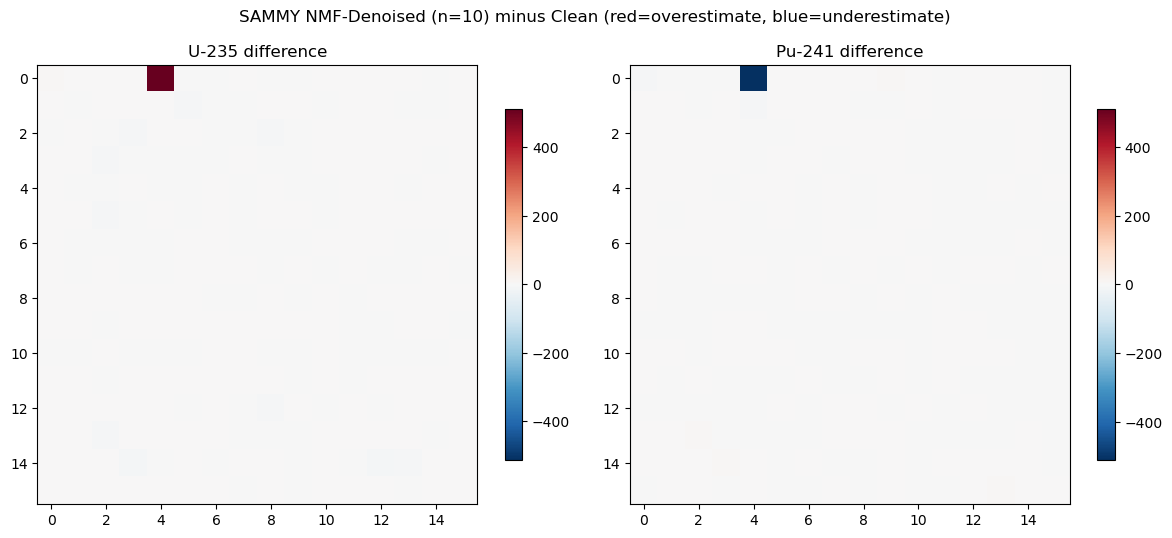


NMF Denoising -> SAMMY (n_incident=2)


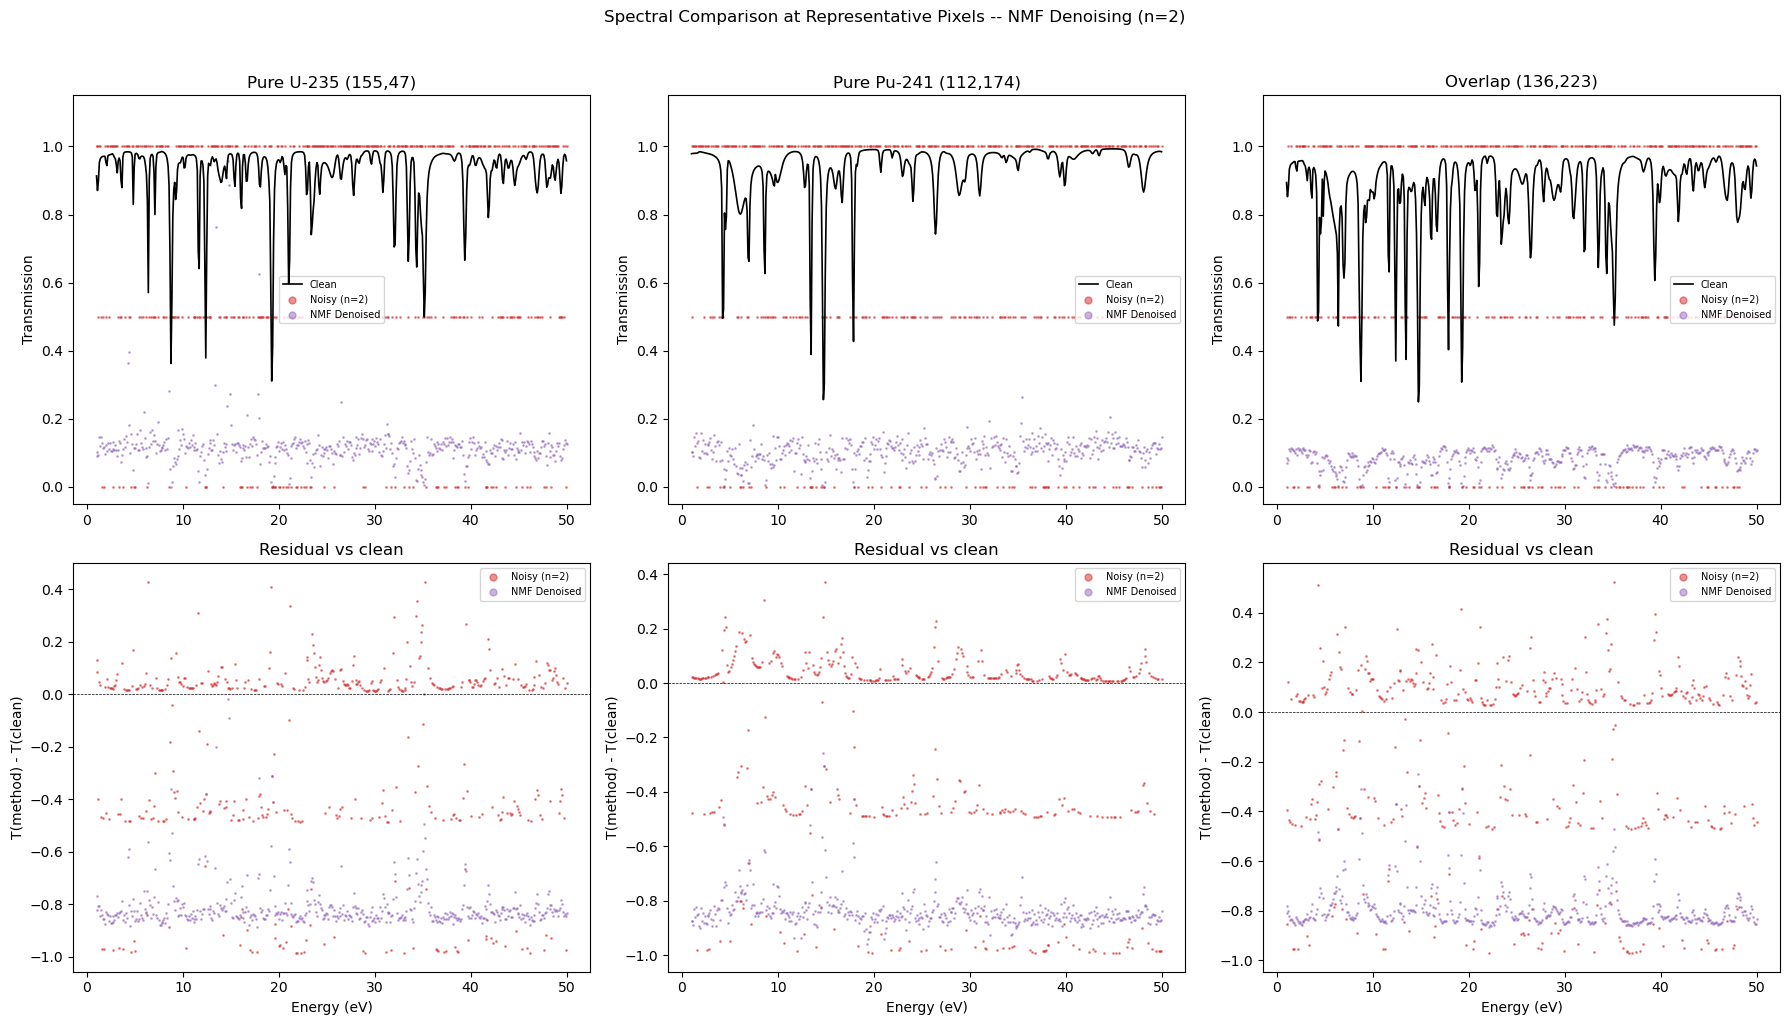

  Running SAMMY on NMF-denoised data...


2026-02-23 11:54:25 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 256 success, 0 failed


  Done in 271s, 256 pixels OK


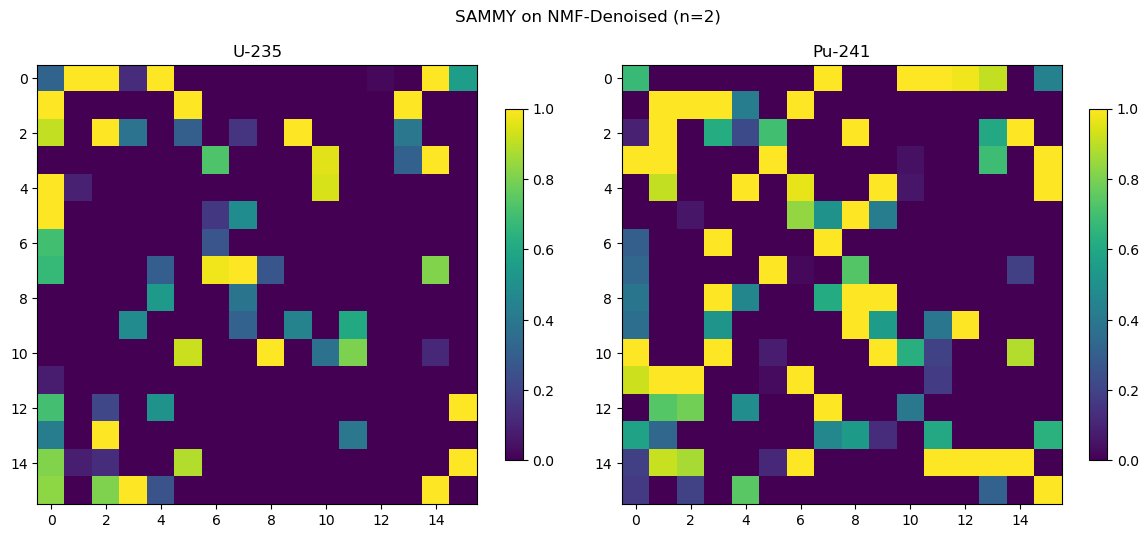

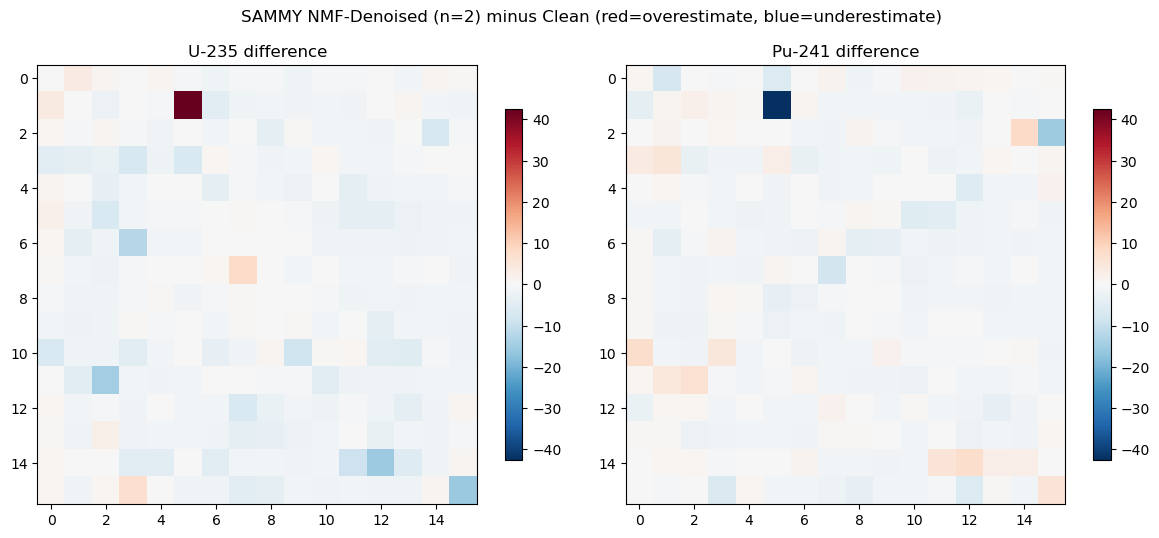

In [18]:
# --- Stage 4b: NMF denoising → SAMMY fitting ---
# NMF projects noisy data onto a low-rank subspace, filtering noise.
# We feed the reconstructed (denoised) spectra to SAMMY.

nmf_denoised_sammy_results = {}

for n_inc in [10, 2]:
    print(f"\n{'='*50}")
    print(f"NMF Denoising -> SAMMY (n_incident={n_inc})")
    print(f"{'='*50}")

    hs_noisy = type(hyperspectral)(
        data=noisy_data[n_inc], energy=energy,
        uncertainty=np.maximum(0.02 * np.abs(noisy_data[n_inc]) + 1e-4, 1e-4).astype(np.float32),
        source_file=hyperspectral.source_file,
    )
    # 4 components: 2 signal + 2 for absorbing noise/baseline shifts
    nmf_dn = NMFRecovery(n_components=4, max_iter=200, random_state=42)
    hs_denoised = nmf_dn.denoise(hs_noisy)

    # Show spectral comparison at representative pixels
    fig = plot_spectra_at_pixels(
        [hyperspectral.data, noisy_data[n_inc], hs_denoised.data],
        ["Clean", f"Noisy (n={n_inc})", "NMF Denoised"],
        title_suffix=f" -- NMF Denoising (n={n_inc})",
    )
    save_fig(fig, f"04b_nmf_denoise_spectra_n{n_inc}")

    # Run SAMMY on NMF-denoised data
    print(f"  Running SAMMY on NMF-denoised data...")
    t0 = time.time()
    result = run_sammy_strided(hs_denoised.data)
    elapsed = time.time() - t0
    n_ok = result.success_mask.sum()
    print(f"  Done in {elapsed:.0f}s, {n_ok} pixels OK")
    nmf_denoised_sammy_results[n_inc] = result

    # Maps + difference
    fig = plot_abundance_maps(result, f"SAMMY on NMF-Denoised (n={n_inc})")
    save_fig(fig, f"04b_sammy_nmf_n{n_inc}_maps")

    fig = plot_difference_maps(result, results_sammy_clean,
                               f"SAMMY NMF-Denoised (n={n_inc}) minus Clean")
    save_fig(fig, f"04b_sammy_nmf_n{n_inc}_diff")



Semi-NMF -> SAMMY (n_incident=10)


  Semi-NMF reconstruction: 1.7s


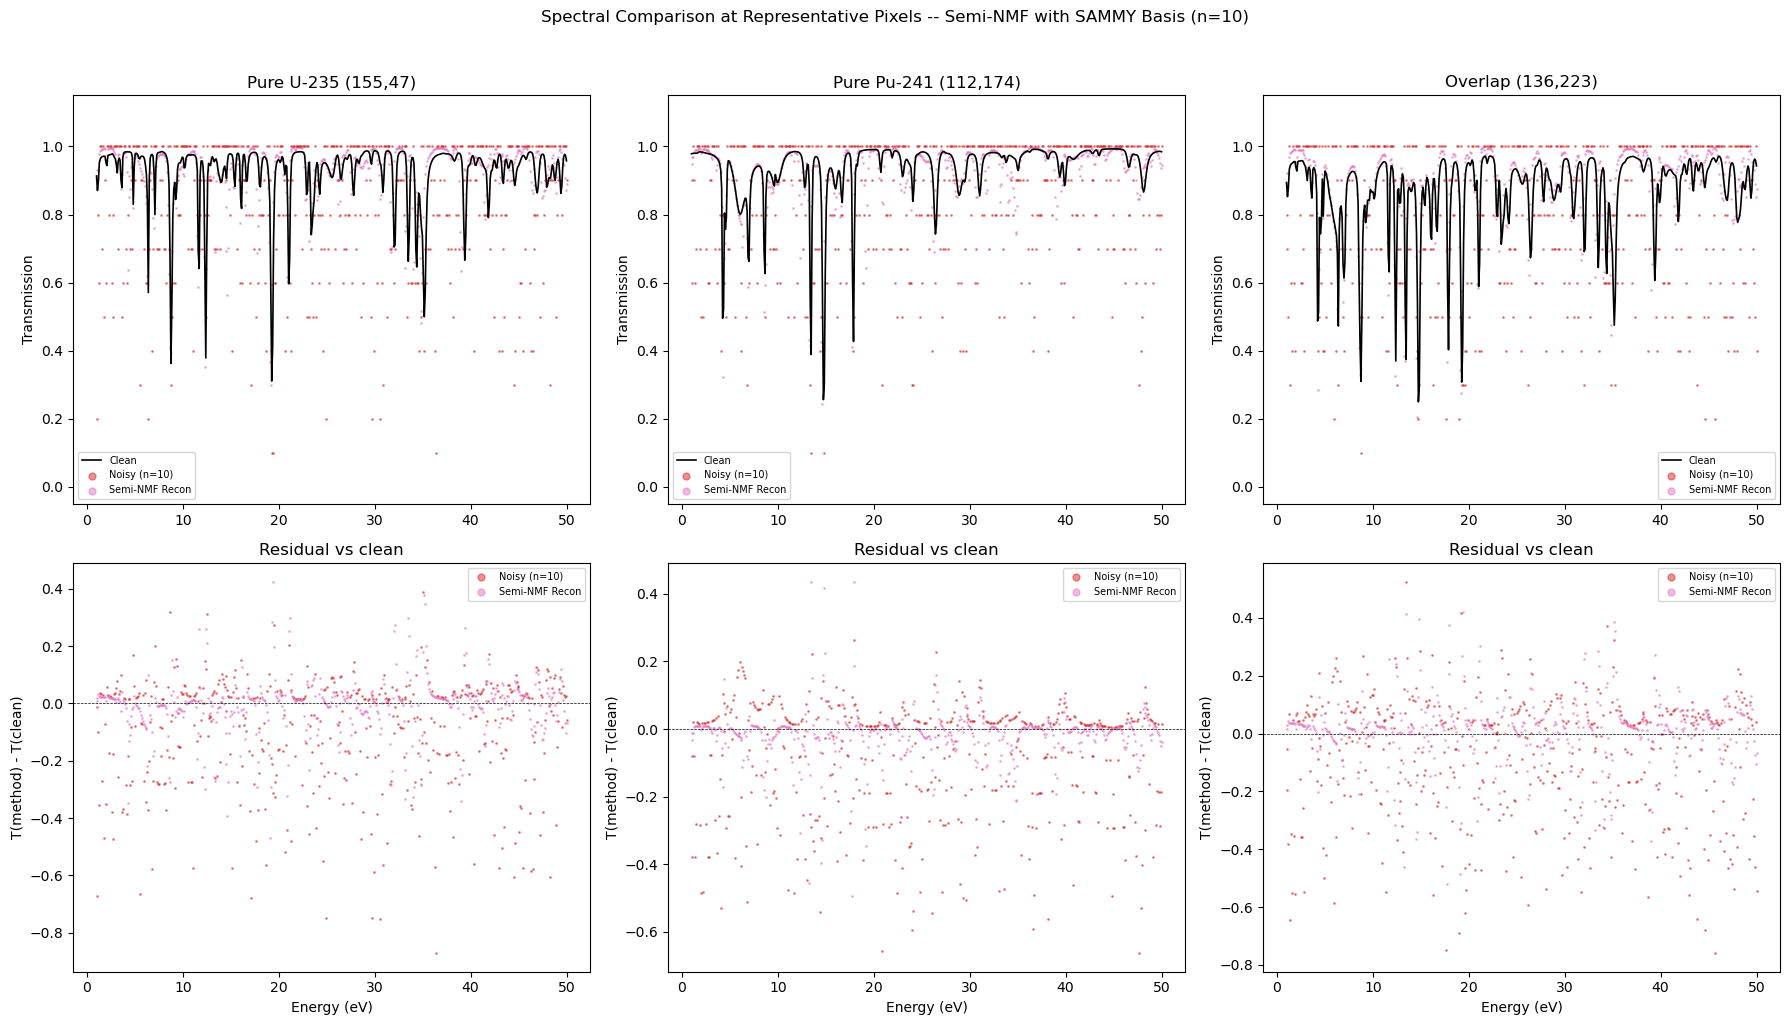

  Running SAMMY on Semi-NMF reconstructed data...


2026-02-23 11:58:55 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 256 success, 0 failed


  Done in 267s, 256 pixels OK


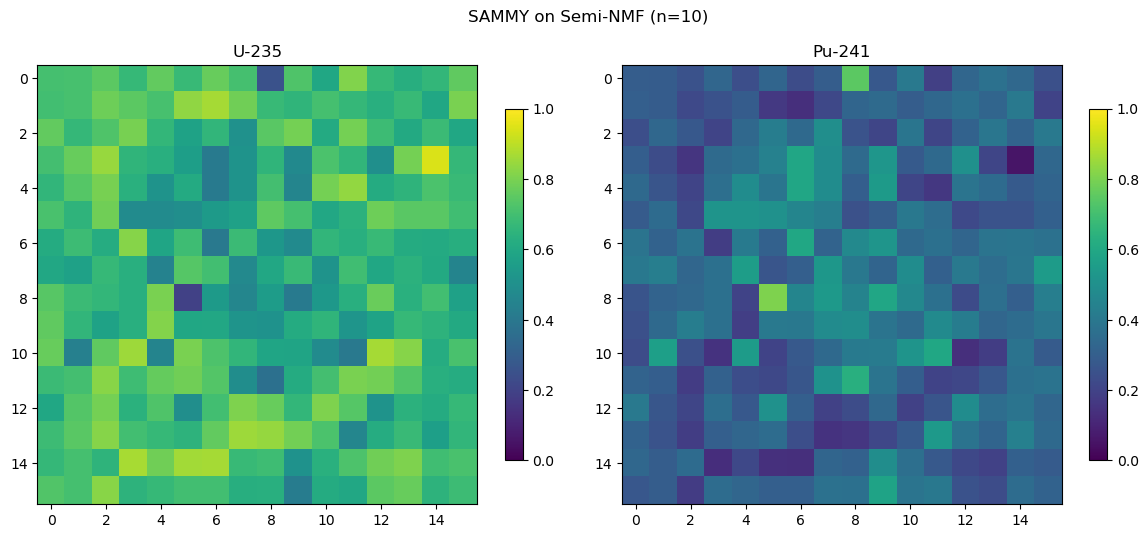

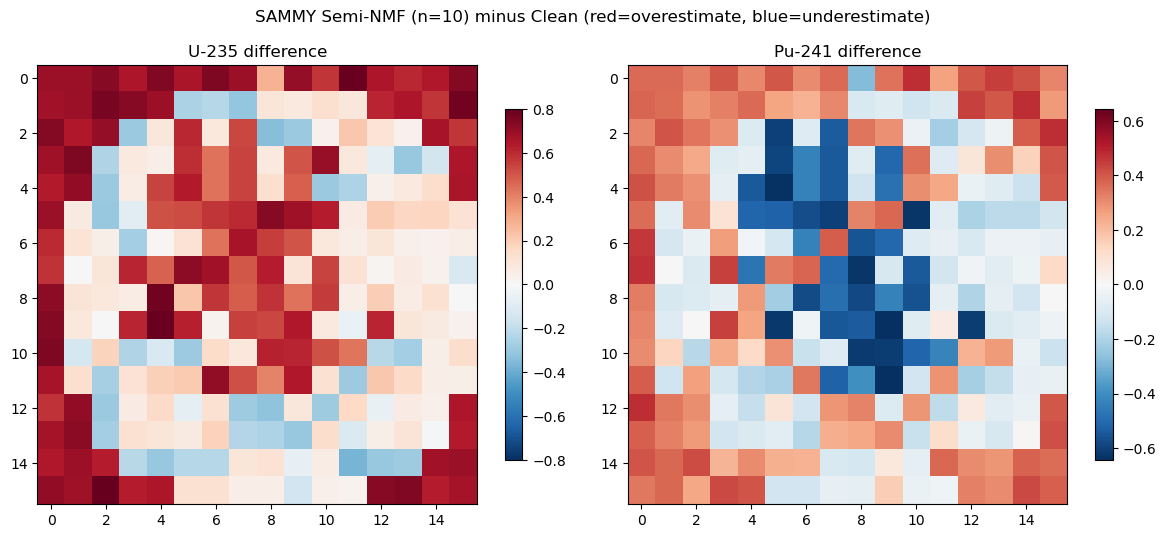


Semi-NMF -> SAMMY (n_incident=2)


  Semi-NMF reconstruction: 1.8s


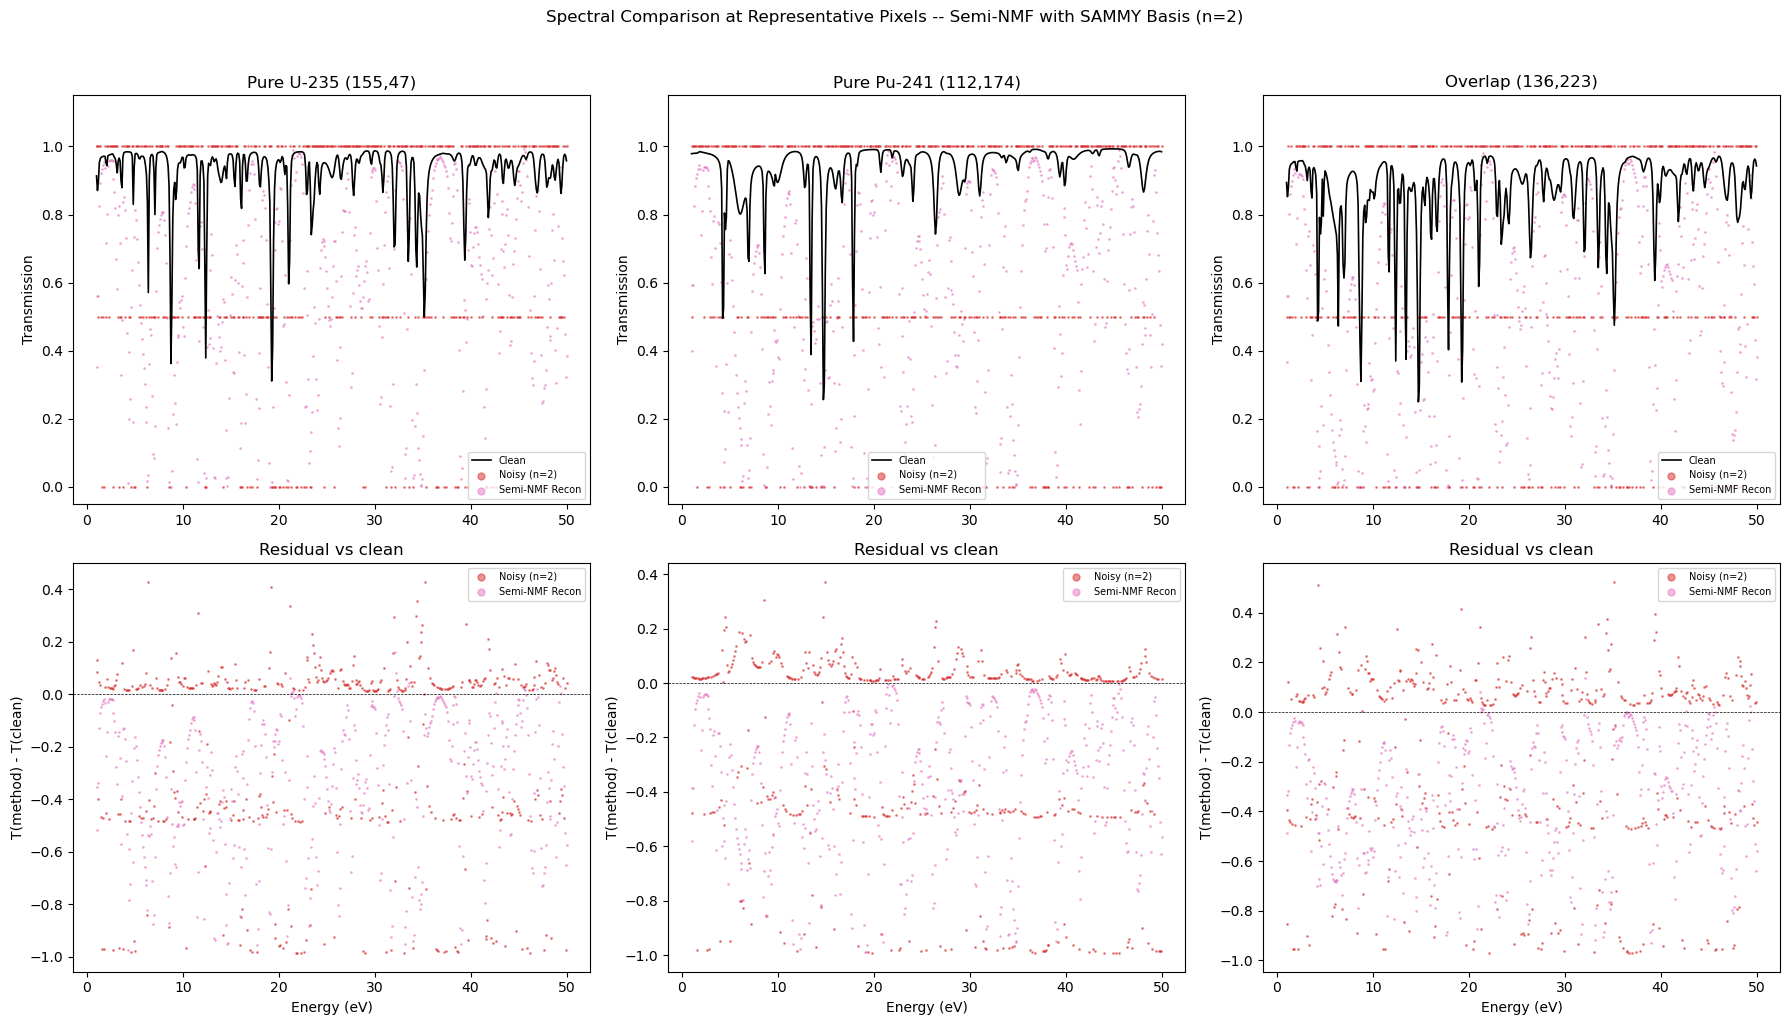

  Running SAMMY on Semi-NMF reconstructed data...


2026-02-23 12:03:30 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:743 - Retry round 1/1: 8 pixels to retry


2026-02-23 12:03:42 | WARNING  | pleiades.imaging.orchestrator:fit_pixels:842 - Batch fitting complete: 248 success, 8 failed


  Done in 283s, 248 pixels OK


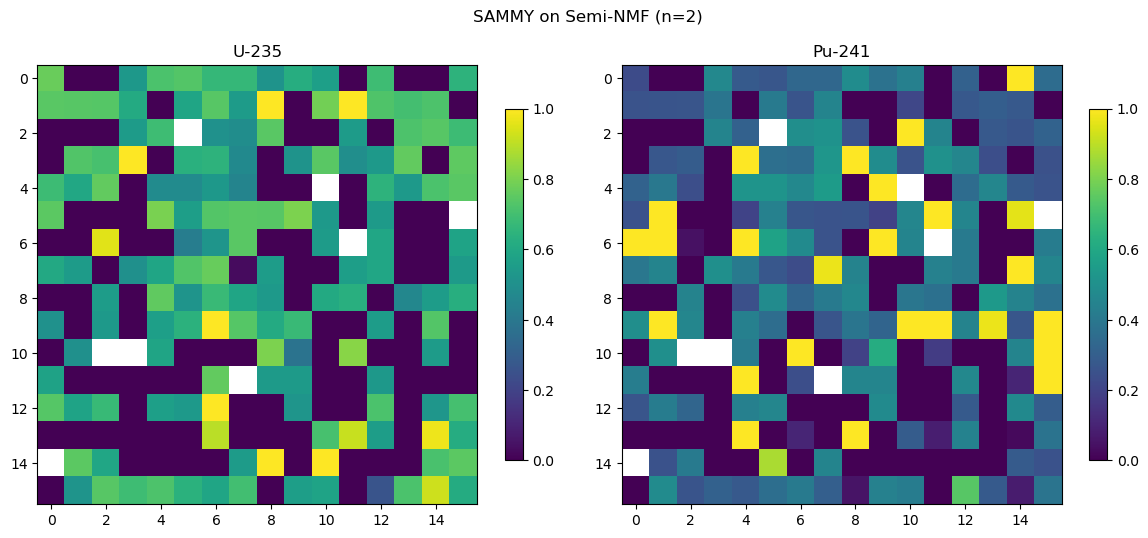

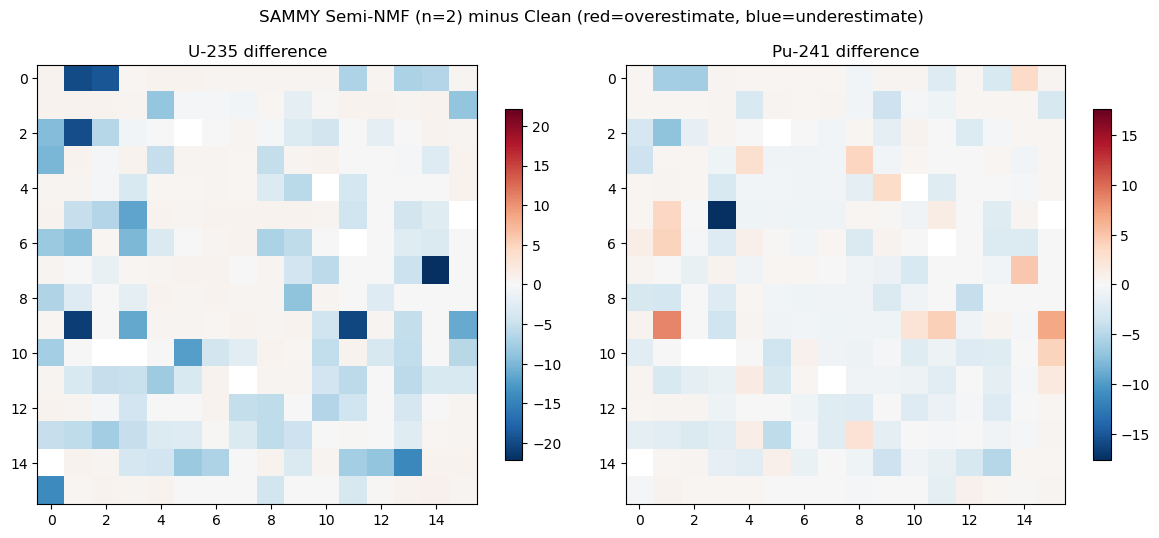

In [19]:
# --- Stage 4c: Semi-NMF with SAMMY Basis ---
# Fix H = SAMMY reference absorption spectra, solve only for W (spatial coefficients)
# via per-pixel NNLS, reconstruct T = exp(-W @ H).
# This constrains the denoised spectra to be linear combinations of SAMMY physics.

from scipy.optimize import nnls as scipy_nnls

def semi_nmf_reconstruct(data_cube, ref_spectra_list):
    """Semi-NMF with fixed SAMMY basis."""
    n_e, h, w = data_cube.shape
    n_iso = len(ref_spectra_list)
    H = np.column_stack([r.absorption for r in ref_spectra_list])  # (n_energy, n_iso)

    recon = np.ones_like(data_cube)
    coeffs = np.zeros((n_iso, h, w))

    for r in range(h):
        for c in range(w):
            T_obs = np.clip(data_cube[:, r, c], 1e-6, 1.0 - 1e-6)
            A_obs = -np.log(T_obs)
            if A_obs.max() < 1e-4:
                continue
            w_vec, _ = scipy_nnls(H, A_obs)
            coeffs[:, r, c] = w_vec
            recon[:, r, c] = np.exp(-(H @ w_vec))

    return recon, coeffs

# Apply Semi-NMF and feed to SAMMY
semi_nmf_sammy_results = {}

for n_inc in [10, 2]:
    print(f"\n{'='*50}")
    print(f"Semi-NMF -> SAMMY (n_incident={n_inc})")
    print(f"{'='*50}")

    t0 = time.time()
    recon, coeffs = semi_nmf_reconstruct(noisy_data[n_inc], ref_spectra)
    print(f"  Semi-NMF reconstruction: {time.time()-t0:.1f}s")

    # Spectral comparison
    fig = plot_spectra_at_pixels(
        [hyperspectral.data, noisy_data[n_inc], recon],
        ["Clean", f"Noisy (n={n_inc})", "Semi-NMF Recon"],
        title_suffix=f" -- Semi-NMF with SAMMY Basis (n={n_inc})",
    )
    save_fig(fig, f"04c_semi_nmf_spectra_n{n_inc}")

    # Run SAMMY on Semi-NMF reconstructed data
    print(f"  Running SAMMY on Semi-NMF reconstructed data...")
    t0 = time.time()
    result = run_sammy_strided(recon)
    elapsed = time.time() - t0
    n_ok = result.success_mask.sum()
    print(f"  Done in {elapsed:.0f}s, {n_ok} pixels OK")
    semi_nmf_sammy_results[n_inc] = result

    # Maps + difference
    fig = plot_abundance_maps(result, f"SAMMY on Semi-NMF (n={n_inc})")
    save_fig(fig, f"04c_sammy_semi_nmf_n{n_inc}_maps")

    fig = plot_difference_maps(result, results_sammy_clean,
                               f"SAMMY Semi-NMF (n={n_inc}) minus Clean")
    save_fig(fig, f"04c_sammy_semi_nmf_n{n_inc}_diff")


---

# Grand Comparison

Side-by-side abundance maps for all methods at each noise level, plus the clean baseline.
This lets us visually compare how well each preprocessing method preserves the spatial
isotope separation before SAMMY fitting.


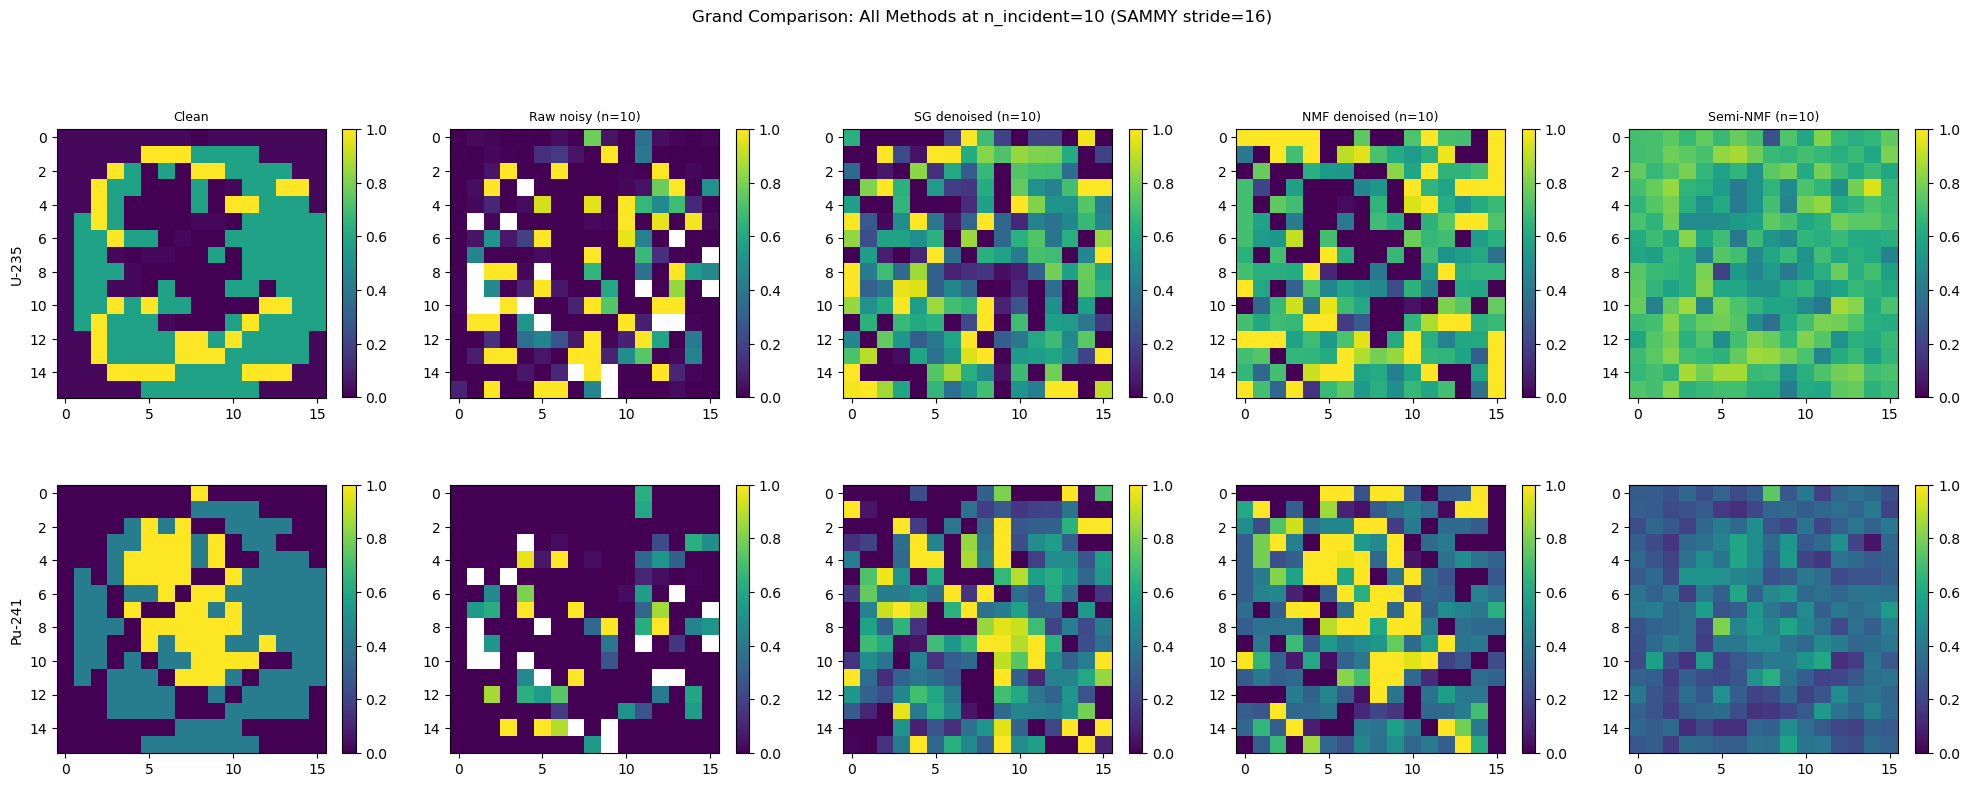

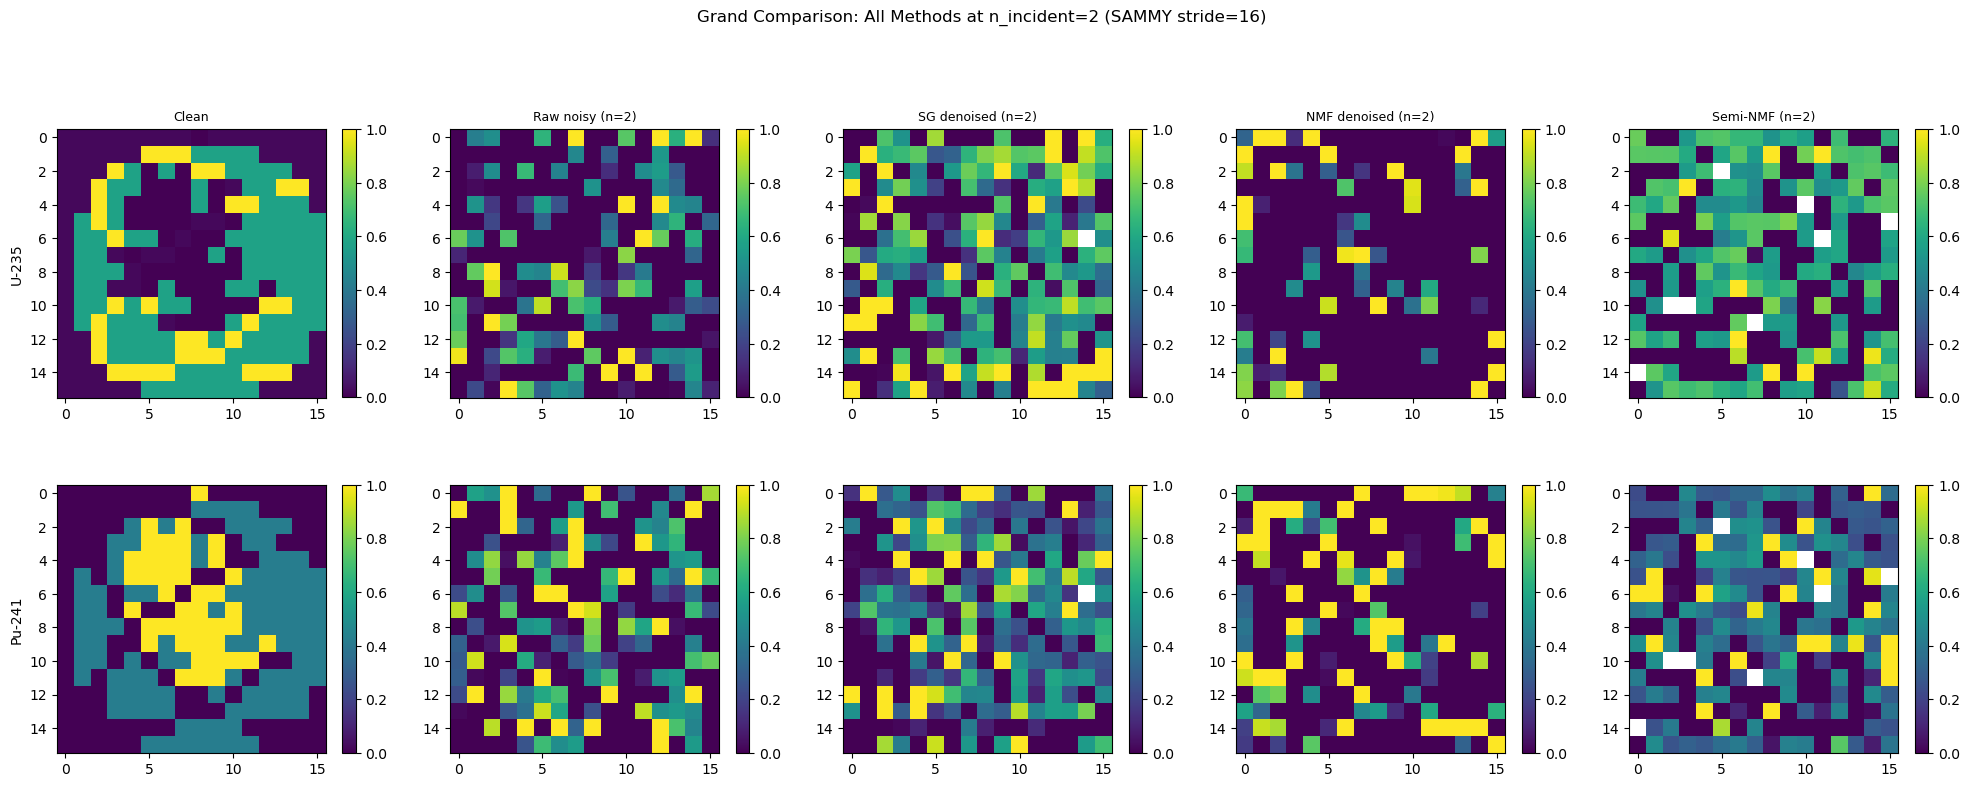

In [20]:
# --- Grand visual comparison ---
# For each noise level, show all SAMMY-based results side by side.

for n_inc in [10, 2]:
    methods = [
        ("Clean", results_sammy_clean),
        (f"Raw noisy (n={n_inc})", sammy_noisy_results.get(n_inc)),
        (f"SG denoised (n={n_inc})", sammy_denoised_results.get(n_inc)),
        (f"NMF denoised (n={n_inc})", nmf_denoised_sammy_results.get(n_inc)),
        (f"Semi-NMF (n={n_inc})", semi_nmf_sammy_results.get(n_inc)),
    ]
    # Filter out None
    methods = [(name, r) for name, r in methods if r is not None]

    n_methods = len(methods)
    fig, axes = plt.subplots(2, n_methods, figsize=(4 * n_methods, 8))

    for col, (mname, result) in enumerate(methods):
        for row, iso in enumerate(config.isotopes):
            amap = result.abundance_maps[row]
            sub = amap[::SAMMY_STRIDE, ::SAMMY_STRIDE]
            im = axes[row, col].imshow(sub, cmap="viridis", origin="upper",
                                        interpolation="nearest", vmin=0, vmax=1)
            if row == 0:
                axes[row, col].set_title(mname, fontsize=9)
            if col == 0:
                axes[row, col].set_ylabel(iso)
            fig.colorbar(im, ax=axes[row, col], shrink=0.7)

    fig.suptitle(f"Grand Comparison: All Methods at n_incident={n_inc} "
                 f"(SAMMY stride={SAMMY_STRIDE})", y=1.02)
    fig.tight_layout()
    save_fig(fig, f"05_grand_comparison_n{n_inc}")


---

# Observations

The figures above are the raw experimental output. Examine them to answer:

1. **Noise model** (Stage 1): At what binning level does NNLS recover the correct
   abundances for each noise level? Does the point detector always work?

2. **SAMMY on noise** (Stage 2): How badly do the abundance maps degrade with noise?
   Does SAMMY produce physically nonsensical values (negative abundances, values > 1)?

3. **Traditional denoising** (Stage 3): Do spectral filters visibly improve the SAMMY
   maps? Do they introduce artifacts visible in the spectral residual plots?

4. **NMF approaches** (Stage 4):
   - Does blind NMF's learned basis match the SAMMY references? Where do they differ?
   - Does NMF denoising produce cleaner spectra than Savitzky-Golay (visible in residuals)?
   - Does Semi-NMF (physics-constrained) produce the cleanest reconstruction?
   - Which preprocessing method gives SAMMY the best maps?

5. **Grand comparison**: Which method best preserves the spatial separation of the two logos?
